# Figures and analysis for LEAFs paper

In [2]:
import sbtn_leaf.map_plotting as mp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import polars as pl
import rioxarray as rxr
import matplotlib as mpl
import importlib

## Results

### Terrestrial Acidification
Importing the needed data

In [3]:
# raster
nh3_raster_fp = "../LEAFs/acidification/rasters/acid_nh3.tif"
nox_raster_fp = "../LEAFs/acidification/rasters/acid_nox.tif"
so2_raster_fp = "../LEAFs/acidification/rasters/acid_so2.tif"

#geopackage
acid_er_geom = gpd.read_file("../LEAFs/acidification/soil_erosion_ecoregion.gpkg", layer="geometry_layer")
acid_er_vals = gpd.read_file("../LEAFs/acidification/soil_erosion_ecoregion.gpkg", layer="acid_leaf_ecoregions")

Preparing geopackage

In [4]:
acid_er = acid_er_geom.merge(acid_er_vals.drop(columns="_source_file"), how="left", on="ECO_ID")

In [5]:
acid_er.head()

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,cf,cf_median,cf_std
0,1.0,Adelie Land tundra,11.0,Tundra,Antarctica,AN11,117,"MULTIPOLYGON (((15313733.007 -6878278.25, 1531...",nh3,0.000000,0.000000,0.000000
1,1.0,Adelie Land tundra,11.0,Tundra,Antarctica,AN11,117,"MULTIPOLYGON (((15313733.007 -6878278.25, 1531...",nox,0.000000,0.000000,0.000000
2,1.0,Adelie Land tundra,11.0,Tundra,Antarctica,AN11,117,"MULTIPOLYGON (((15313733.007 -6878278.25, 1531...",so2,0.032829,0.045010,0.019801
3,2.0,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,135,"MULTIPOLYGON (((14211289.839 -328506.485, 1420...",nh3,0.083384,0.083798,0.002258
4,2.0,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,135,"MULTIPOLYGON (((14211289.839 -328506.485, 1420...",nox,0.017149,0.017326,0.000966


Reprojecting to Natural Earth

In [6]:
# geopackage
acid_er_ne = acid_er.to_crs("+proj=natearth")

In [7]:
# nh3
da = rxr.open_rasterio(nh3_raster_fp, masked=True)          # keeps nodata masked
da_ne = da.rio.reproject("+proj=natearth", resampling=1)  # 1 = bilinear
da_ne.rio.to_raster("../paper/acid_nh3_natear.tif")

# nox
da = rxr.open_rasterio(nox_raster_fp, masked=True)          # keeps nodata masked
da_ne = da.rio.reproject("+proj=natearth", resampling=1)  # 1 = bilinear
da_ne.rio.to_raster("../paper/acid_nox_natear.tif")

# so2
da = rxr.open_rasterio(so2_raster_fp, masked=True)          # keeps nodata masked
da_ne = da.rio.reproject("+proj=natearth", resampling=1)  # 1 = bilinear
da_ne.rio.to_raster("../paper/acid_so2_natear.tif")

In [8]:
mp.inspect_raster(so2_raster_fp)

File: ../LEAFs/acidification/rasters/acid_so2.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float64
  Min Value: 0.0
  Max Value: 10.813172542646374
  Mean Value: 0.6030503978571433
  Standard Deviation: 1.0425912985590675


Raster has 10,871 unique values. Min: 0.00. Max: 10.81
Using quantiles
All positives route (quantiles)


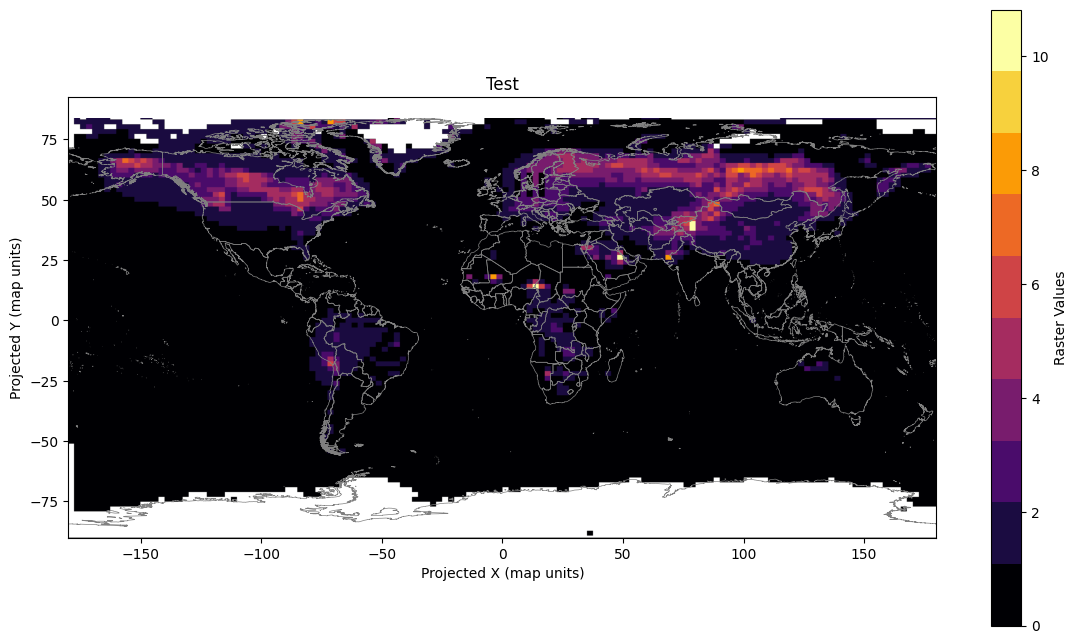

In [9]:
mp.plot_raster_on_world_extremes_cutoff(so2_raster_fp, title="Test", perc_cutoff=0, quantiles=10, cmap="inferno", eliminate_zeros=True)

Now plotting

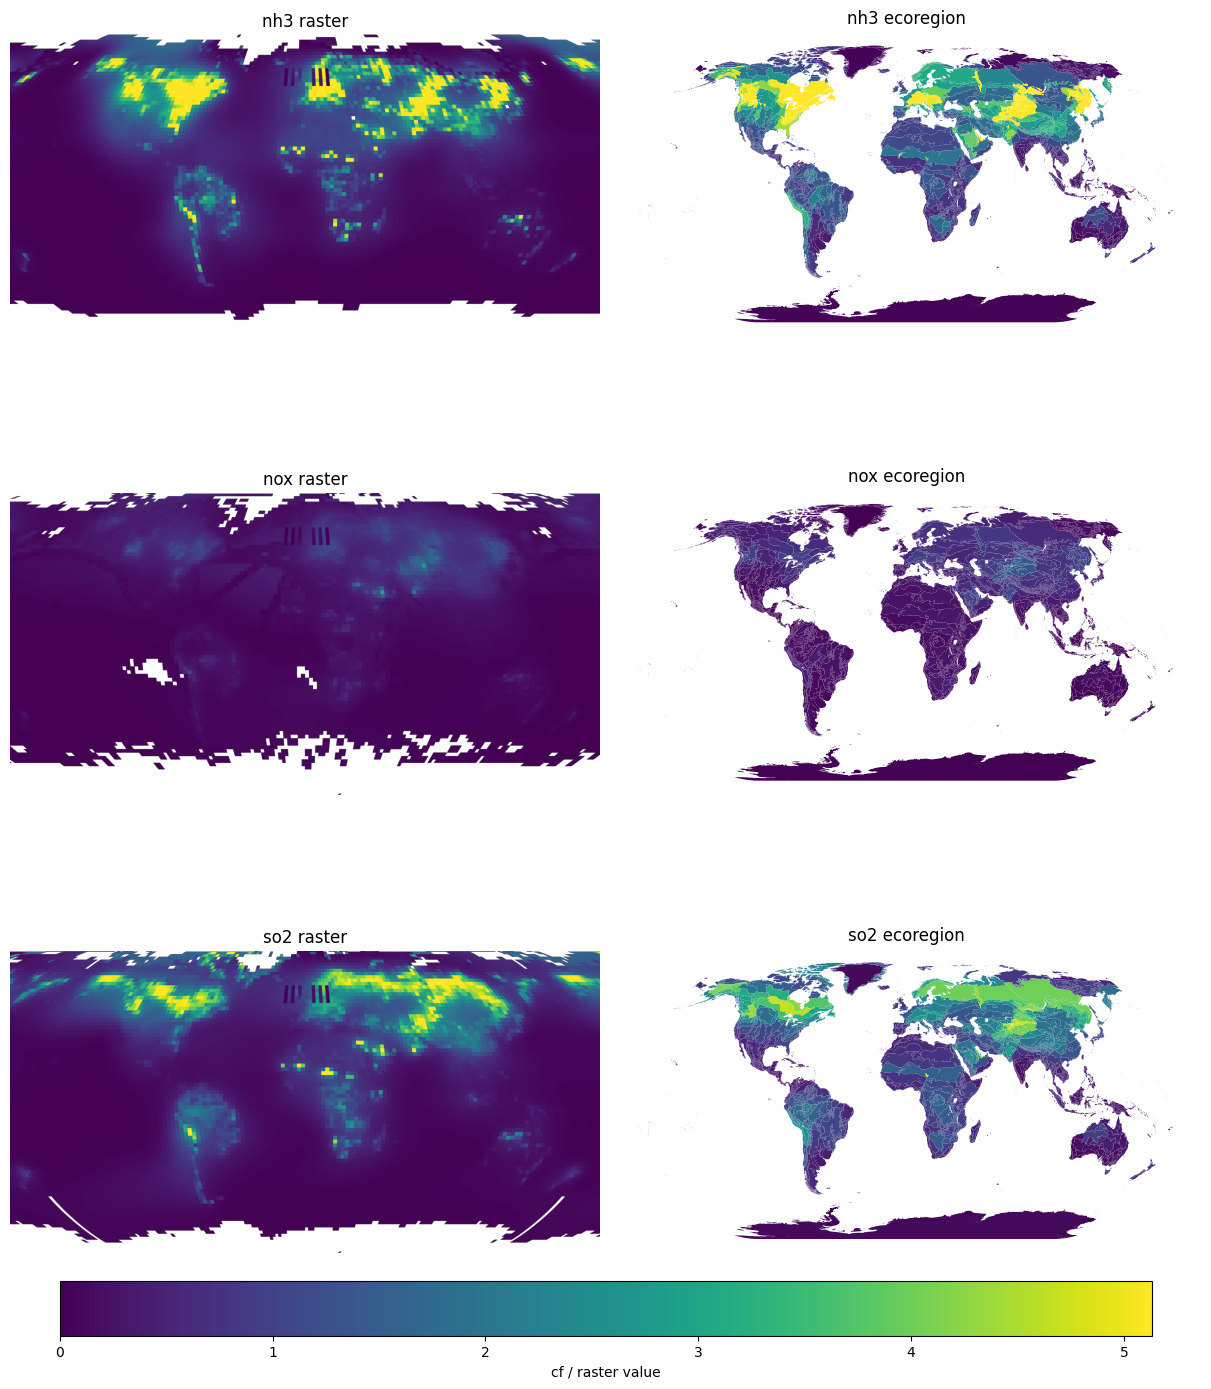

In [10]:
# paths for reprojected natearth rasters (written in an earlier cell)
nh3_ne_fp = "../paper/acid_nh3_natear.tif"
nox_ne_fp = "../paper/acid_nox_natear.tif"
so2_ne_fp = "../paper/acid_so2_natear.tif"

# open rasters (rioxarray already imported as rxr)
da_nh3 = rxr.open_rasterio(nh3_ne_fp, masked=True)
da_nox = rxr.open_rasterio(nox_ne_fp, masked=True)
da_so2 = rxr.open_rasterio(so2_ne_fp, masked=True)

# helper: always return a 2D float array with NaNs
def _arr2d(da):
    arr = da.squeeze().values  # (y,x) or (band,y,x) depending on file
    if arr.ndim == 3:
        arr = arr[0]
    if np.ma.isMaskedArray(arr):
        arr = arr.filled(np.nan)
    return arr.astype("float64", copy=False)

arrs = [_arr2d(da_nh3), _arr2d(da_nox), _arr2d(da_so2)]

# get cf values for each flow
flows = ["nh3", "nox", "so2"]
cf_vals = [
    acid_er_ne.loc[acid_er_ne["flow_name"] == f, "cf"].to_numpy(dtype="float64")
    for f in flows
]

# shared vmin/vmax across rasters and cf values
all_vals = np.concatenate([a.ravel() for a in arrs] + [v.ravel() for v in cf_vals])
all_vals = all_vals[np.isfinite(all_vals)]
# vmin, vmax = all_vals.min(), all_vals.max()
vmin, vmax = np.nanpercentile(all_vals, [1, 99])  # robust global scale

# plotting
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15), constrained_layout=True)

cmap = "viridis"
das = [da_nh3, da_nox, da_so2]

for i, flow in enumerate(flows):
    ax_r = axes[i, 0]
    ax_m = axes[i, 1]

    da = das[i]
    arr = arrs[i]

    # mask zeros (do not plot them)
    arr = np.where(arr == 0, np.nan, arr)

    # extent from coordinates (convert to plain numpy floats)
    x0 = float(da["x"].values.min())
    x1 = float(da["x"].values.max())
    y0 = float(da["y"].values.min())
    y1 = float(da["y"].values.max())
    extent = (x0, x1, y0, y1)

    ax_r.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, origin="upper")
    ax_r.set_title(f"{flow} raster")
    ax_r.set_axis_off()

    subset = acid_er_ne[acid_er_ne["flow_name"] == flow]
    subset.plot(column="cf", ax=ax_m, cmap=cmap, vmin=vmin, vmax=vmax, edgecolor="none")
    ax_m.set_title(f"{flow} ecoregion")
    ax_m.set_axis_off()

# shared colorbar (don’t rely on a particular imshow handle)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="horizontal", fraction=0.04, pad=0.02)
cbar.set_label("cf / raster value")

plt.show()

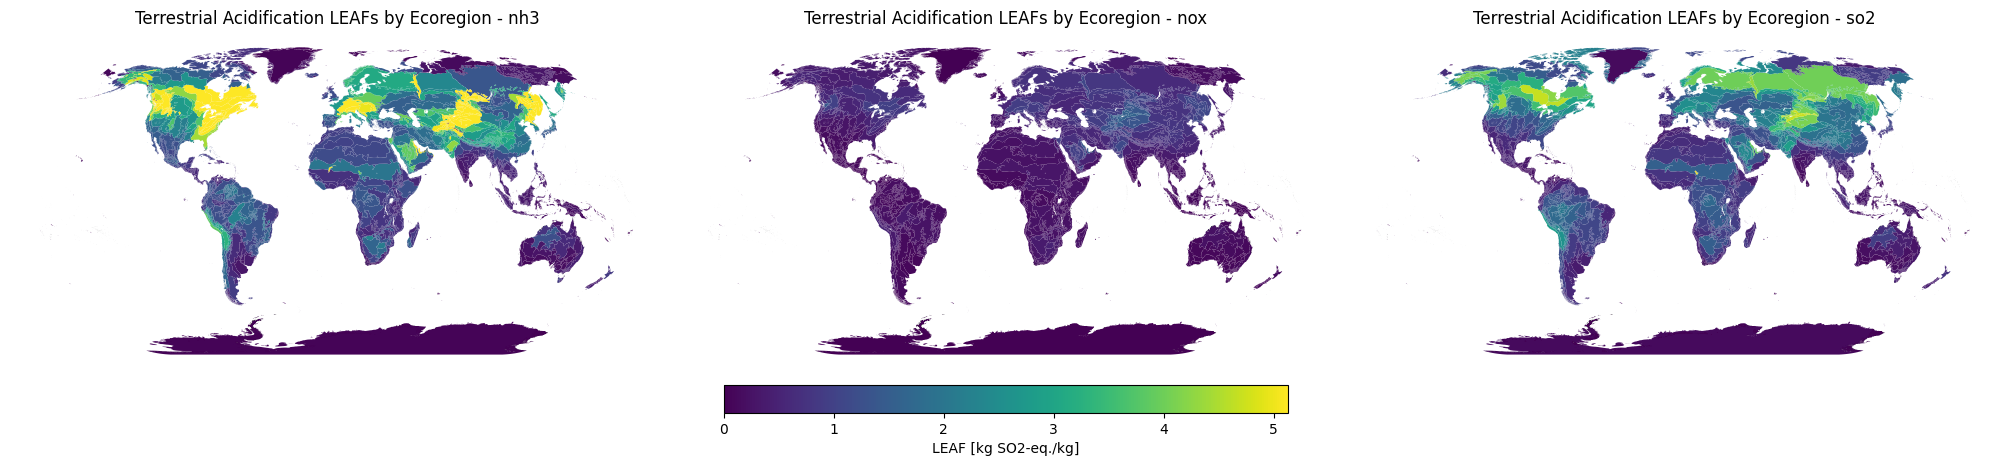

In [11]:
# plot cf for each flow_name (shared vmin/vmax and cmap from previous cells)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), constrained_layout=True)

for ax, flow in zip(axes.ravel(), flows):
    subset = acid_er_ne[acid_er_ne["flow_name"] == flow]
    subset.plot(column="cf", ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, edgecolor="none")
    ax.set_title(f"Terrestrial Acidification LEAFs by Ecoregion - {flow}")
    ax.set_axis_off()

# shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="horizontal", fraction=0.04, pad=0.02).set_label("LEAF [kg SO2-eq./kg]")

plt.show()

Boxplot showing differences per realm

In [12]:
acid_er["flow_name"].unique()

array(['nh3', 'nox', 'so2'], dtype=object)

C:\Users\loyola\AppData\Local\Temp\ipykernel_10276\1796982283.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


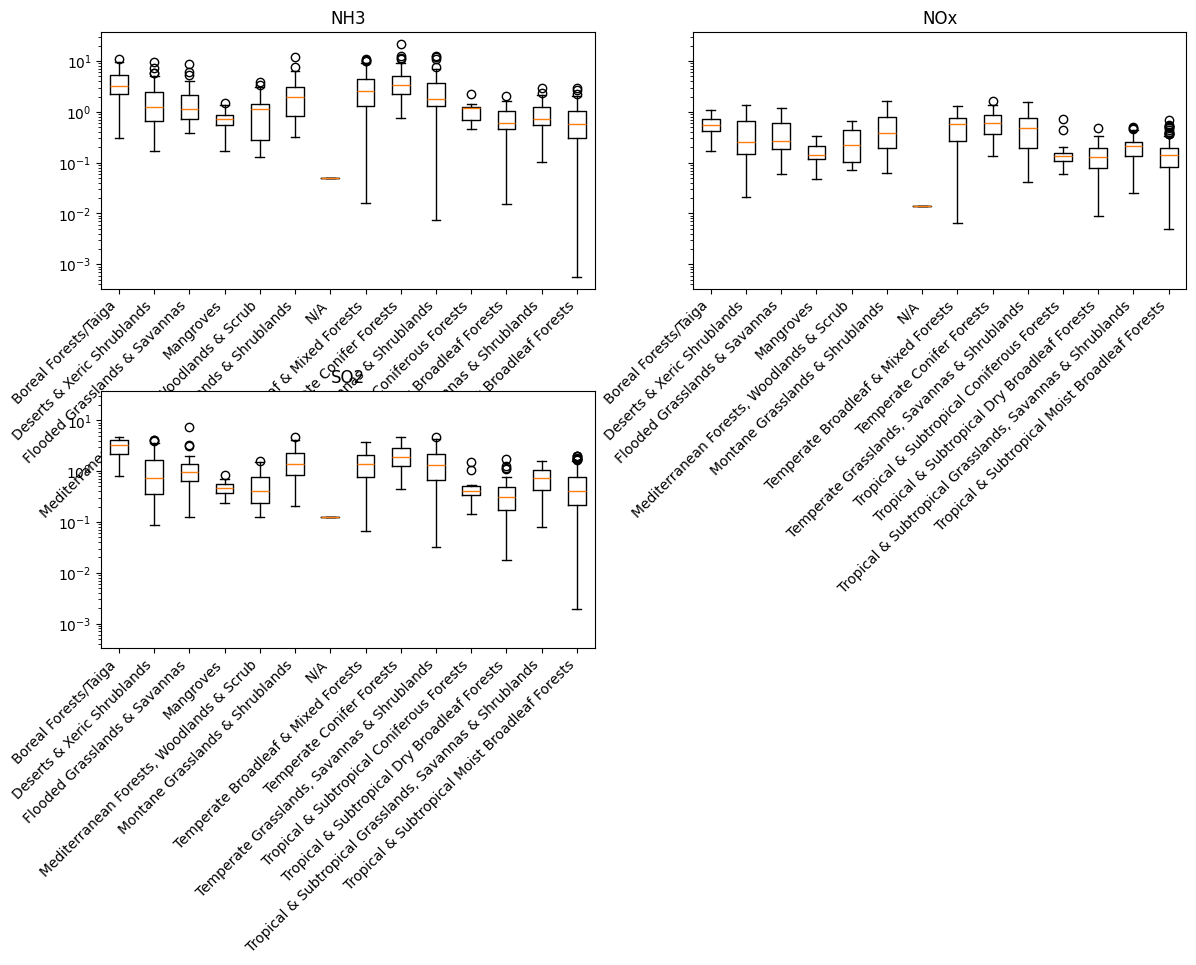

In [13]:
acid_er_noNA = acid_er[acid_er["BIOME_NAME"].notna() & acid_er["cf"].notna() & (acid_er["BIOME_NAME"] != "Tundra")]

def boxdata(df):
    labels = sorted(df["BIOME_NAME"].unique())
    data = [df.loc[df["BIOME_NAME"] == b, "cf"].values for b in labels]
    return data, labels

nh3_lfs = acid_er_noNA[acid_er_noNA["flow_name"] == "nh3"]
nox_lfs = acid_er_noNA[acid_er_noNA["flow_name"] == "nox"]
so2_lfs = acid_er_noNA[acid_er_noNA["flow_name"] == "so2"]

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

data, labels = boxdata(nh3_lfs)
axs[0, 0].boxplot(data, tick_labels=labels)
axs[0, 0].set_title("NH3")

data, labels = boxdata(nox_lfs)
axs[0, 1].boxplot(data, tick_labels=labels)
axs[0, 1].set_title("NOx")

data, labels = boxdata(so2_lfs)
axs[1, 0].boxplot(data, tick_labels=labels)
axs[1, 0].set_title("SO2")

for ax in axs.flat:
    ax.set_yscale("log")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Hide the unused 4th subplot
axs[1, 1].axis("off")

fig.subplots_adjust(hspace=0.4)
plt.show()


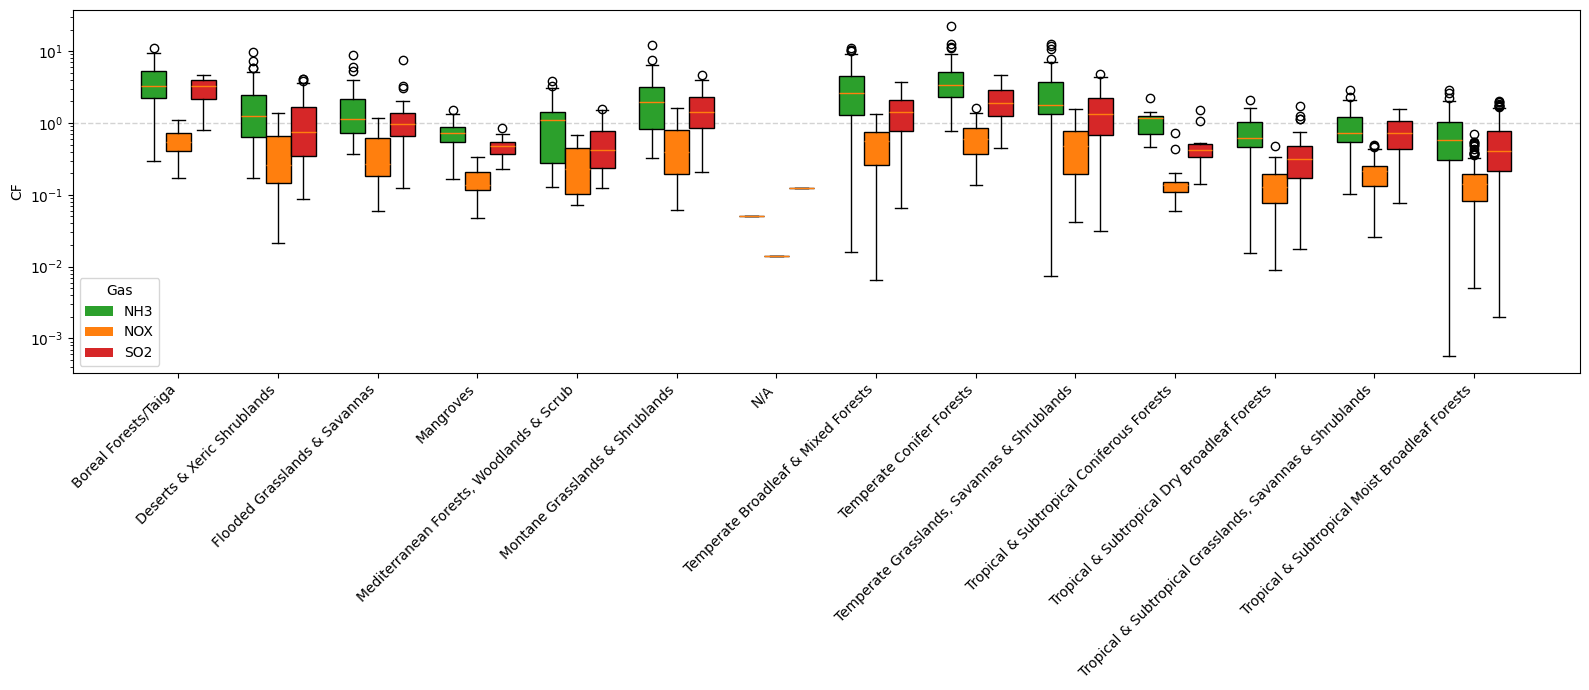

In [14]:
biomes = sorted(acid_er_noNA["BIOME_NAME"].unique())
flows = ["nh3", "nox", "so2"]
colors = {"nh3": "tab:green", "nox": "tab:orange", "so2": "tab:red"}

def collect_data(flow):
    df = acid_er_noNA[acid_er_noNA["flow_name"] == flow]
    return [df.loc[df["BIOME_NAME"] == b, "cf"].values for b in biomes]

data = {flow: collect_data(flow) for flow in flows}

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(biomes))
width = 0.25

ax.axhline(1, linestyle="--", linewidth=1, color = "lightgrey")

for i, flow in enumerate(flows):
    positions = x + (i - 1) * width
    bp = ax.boxplot(
        data[flow],
        positions=positions,
        widths=width,
        patch_artist=True,
        showmeans=False,
        manage_ticks=False,
    )
    for box in bp["boxes"]:
        box.set_facecolor(colors[flow])



# X axis
ax.set_xticks(x)
ax.set_xticklabels(biomes, rotation=45, ha="right")

# Y axis
ax.set_yscale("log")
ax.set_ylabel("CF")

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=colors[f], label=f.upper()) for f in flows
]
ax.legend(handles=legend_handles, title="Gas")

fig.tight_layout()
plt.show()


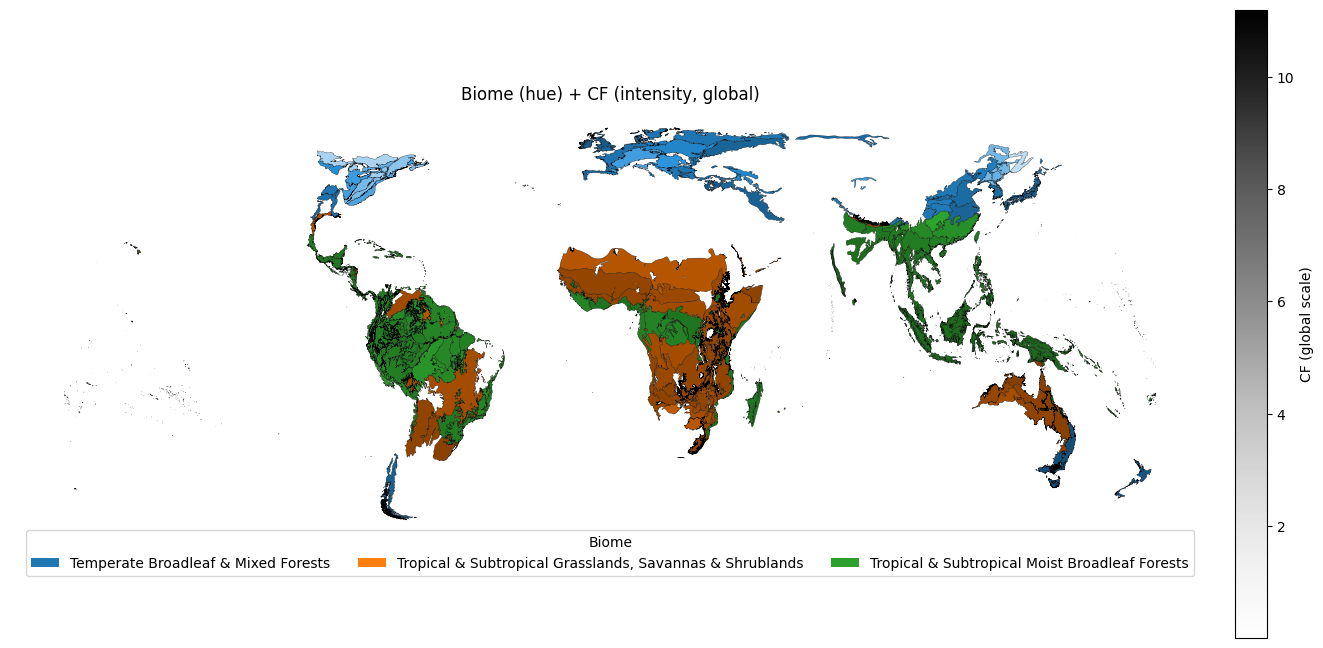

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
import colorsys

# --- Data ---
gdf = acid_er.copy()
gdf = gdf[gdf["BIOME_NAME"].notna() & gdf["cf"].notna()].copy()
gdf = gdf[(gdf["flow_name"]=="nh3") & (gdf["BIOME_NAME"].isin(['Temperate Broadleaf & Mixed Forests','Tropical & Subtropical Grasslands, Savannas & Shrublands', 'Tropical & Subtropical Moist Broadleaf Forests']))]

# --- biome base colors (categorical) ---
biomes = sorted(gdf["BIOME_NAME"].unique())
cmap = plt.get_cmap("tab10")
biome_base = {b: cmap(i % cmap.N) for i, b in enumerate(biomes)}

# --- global normalization for CF intensity ---
#vmin, vmax = np.nanpercentile(gdf["cf"], [1, 99])  # robust global scale
vmin = np.min(gdf["cf"])
vmax = np.max(gdf["cf"])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
gdf["_cf01"] = norm(gdf["cf"].to_numpy())

def biome_intensity_color(base_rgba, t, lo=0.25, hi=0.85):
    r, g, b, a = base_rgba
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l2 = lo + t * (hi - lo)           # lightness encodes CF
    r2, g2, b2 = colorsys.hls_to_rgb(h, l2, s)
    return (r2, g2, b2, 1.0)

gdf["_plot_color"] = [
    biome_intensity_color(biome_base[b], t)
    for b, t in zip(gdf["BIOME_NAME"], gdf["_cf01"])
]

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 8))
gdf.plot(ax=ax, color=gdf["_plot_color"], linewidth=0.2, edgecolor="black")
ax.set_axis_off()
ax.set_title("Biome (hue) + CF (intensity, global)")

# --- biome legend (categorical) ---
handles = [Patch(facecolor=biome_base[b], edgecolor="none", label=b) for b in biomes]
ax.legend(
    handles=handles,
    title="Biome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True
)

# --- global CF intensity legend (continuous) ---
# Use a neutral grayscale ramp so it reads as "intensity" not "biome color"
sm = ScalarMappable(norm=norm, cmap="Greys")
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("CF (global scale)")

ax.legend(
    handles=handles,
    title="Biome",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=True
)

plt.tight_layout()
plt.show()


## SOC

### Loading data


In [16]:
soc_er_gpkg_fp = "../LEAFs/soil_erosion/soil_erosion_ecoregion.gpkg"

soc_er_geometries = gpd.read_file(soc_er_gpkg_fp, layer="geometry_layer")
soc_er_geometries = soc_er_geometries.to_crs("+proj=natearth")

soc_er_values = gpd.read_file(soc_er_gpkg_fp, layer="se_leaf_ecoregions").drop(columns = "_source_file")

In [17]:
soc_er = soc_er_geometries.merge(soc_er_values, on="OBJECTID", how="left")

In [18]:
soc_er.sort_values(by=["cf"], ascending=False).head()

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,cf,cf_median,cf_std
25999,328.0,Huon Peninsula montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,141,"MULTIPOLYGON (((14110579.229 -616085.784, 1411...",Urban,2052.479492,1900.610229,1.098878e+03
19279,244.0,Eastern Panamanian montane forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,461,"MULTIPOLYGON (((-7529477.22 818268.547, -75297...",Urban,1899.165649,1697.285156,1.086563e+03
13999,176.0,Comoros forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Afrotropic,AF01,4,"MULTIPOLYGON (((4352376.706 -1440618.912, 4352...",Urban,1881.906982,1881.906982,0.000000e+00
56079,706.0,Sulawesi montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,157,"MULTIPOLYGON (((11638542.212 -547151.325, 1163...",Urban,1803.205200,1645.490356,1.004601e+03
20079,254.0,Enriquillo wetlands,9.0,Flooded Grasslands & Savannas,Neotropic,NO09,580,"MULTIPOLYGON (((-6552040.314 2039394.279, -655...",Urban,1800.513428,1800.513428,2.273737e-13


Filtering out urban...

In [19]:
soc_er = soc_er[soc_er["flow_name"] != "Urban"]

In [20]:
soc_er.sort_values(by=["cf"], ascending=False).head(20)

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,cf,cf_median,cf_std
50516,636.0,Sinú Valley dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,546,"MULTIPOLYGON (((-7050105.559 1243387.804, -704...",Irrigated_Sweet_potatoes,1434.916382,1434.916382,0.000000
50553,636.0,Sinú Valley dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,546,"MULTIPOLYGON (((-7050105.559 1243387.804, -704...",Rainfed_Sweet_potatoes,1434.916382,1434.916382,0.000000
27706,350.0,Jamaican dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,535,"MULTIPOLYGON (((-7279325.404 2011958.864, -727...",Irrigated_Potatoes,1317.045288,1317.045288,0.000000
27743,350.0,Jamaican dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,535,"MULTIPOLYGON (((-7279325.404 2011958.864, -727...",Rainfed_Potatoes,1317.045288,1317.045288,0.000000
50539,636.0,Sinú Valley dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,546,"MULTIPOLYGON (((-7050105.559 1243387.804, -704...",Rainfed_Maize_residues_removed_from_the_field,1090.536377,1090.536377,0.000000
50501,636.0,Sinú Valley dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,546,"MULTIPOLYGON (((-7050105.559 1243387.804, -704...",Irrigated_Maize_residues_removed_from_the_field,1090.536377,1090.536377,0.000000
15226,192.0,Cuban cactus scrub,13.0,Deserts & Xeric Shrublands,Neotropic,NO13,600,"MULTIPOLYGON (((-7382242.95 2229705.905, -7383...",Irrigated_Potatoes,1050.283325,1247.864014,485.302948
15263,192.0,Cuban cactus scrub,13.0,Deserts & Xeric Shrublands,Neotropic,NO13,600,"MULTIPOLYGON (((-7382242.95 2229705.905, -7383...",Rainfed_Potatoes,1050.283325,1247.864014,485.302948
25956,328.0,Huon Peninsula montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,141,"MULTIPOLYGON (((14110579.229 -616085.784, 1411...",Irrigated_Sweet_potatoes,1032.264648,967.089539,545.638550
25993,328.0,Huon Peninsula montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,141,"MULTIPOLYGON (((14110579.229 -616085.784, 1411...",Rainfed_Sweet_potatoes,1032.264648,967.089539,545.638550


### Checking potatoes

Checking what happened with potatoes...

In [21]:
soc_pot_irr = soc_er[soc_er["flow_name"]=="Irrigated_Potatoes"]

In [22]:
threshold = soc_pot_irr["cf"].dropna().quantile(0.99)
top1 = soc_pot_irr[soc_pot_irr["cf"] >= threshold].sort_values("cf", ascending=False)
print(f"99th percentile threshold: {threshold} — {len(top1)} rows")
top1.head()

99th percentile threshold: 873.563864746094 — 8 rows


,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,cf,cf_median,cf_std
27706,350.0,Jamaican dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,535,"MULTIPOLYGON (((-7279325.404 2011958.864, -727...",Irrigated_Potatoes,1317.045288,1317.045288,0.000000
15226,192.0,Cuban cactus scrub,13.0,Deserts & Xeric Shrublands,Neotropic,NO13,600,"MULTIPOLYGON (((-7382242.95 2229705.905, -7383...",Irrigated_Potatoes,1050.283325,1247.864014,485.302948
20026,254.0,Enriquillo wetlands,9.0,Flooded Grasslands & Savannas,Neotropic,NO09,580,"MULTIPOLYGON (((-6552040.314 2039394.279, -655...",Irrigated_Potatoes,1005.479980,1005.479980,0.000000
25946,328.0,Huon Peninsula montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,141,"MULTIPOLYGON (((14110579.229 -616085.784, 1411...",Irrigated_Potatoes,986.386902,967.089539,390.295319
27386,346.0,Isthmian-Pacific moist forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,471,"MULTIPOLYGON (((-7908309.898 817211.205, -7908...",Irrigated_Potatoes,943.579346,875.965088,309.054962


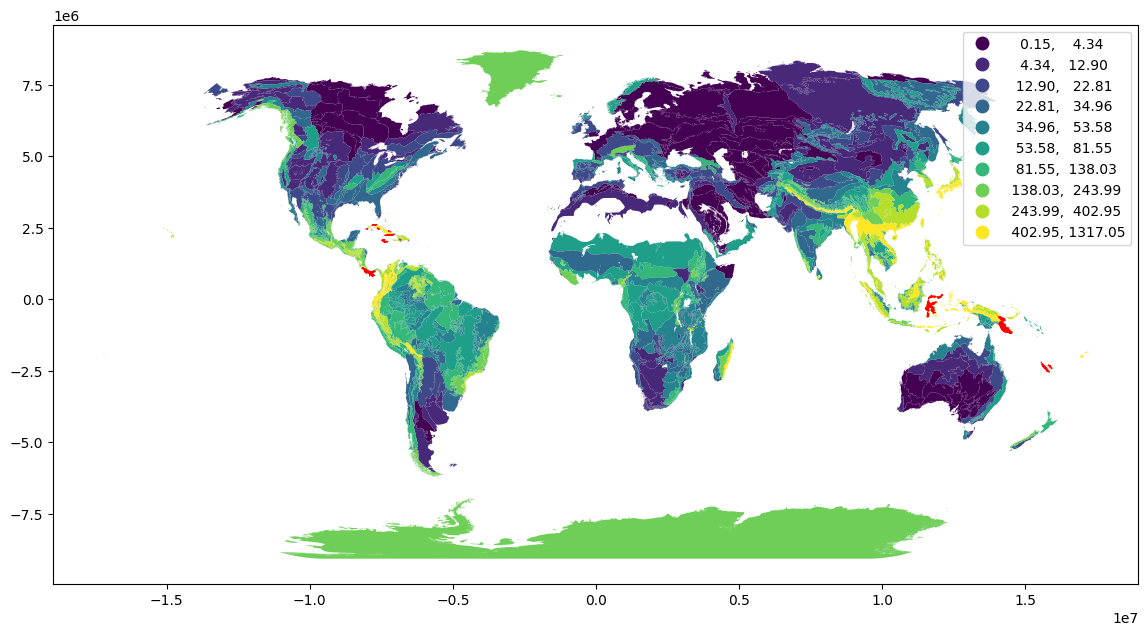

In [23]:
fig, ax = plt.subplots(figsize=(14, 8))

soc_pot_irr.plot(
    ax=ax,
    column="cf",
    legend=True,
    scheme="quantiles",
    k = 10
)

top1.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    edgecolor="red",
)

plt.show()


Loading the raster

In [24]:
soc_pot_irr_raster = "../LEAFs/SOC/rasters/Potato_irr_2030y_SOC.tif"

Raster has 1,285,480 unique values. Min: 4.92. Max: 173.95
Using quantiles
All positives route (quantiles)


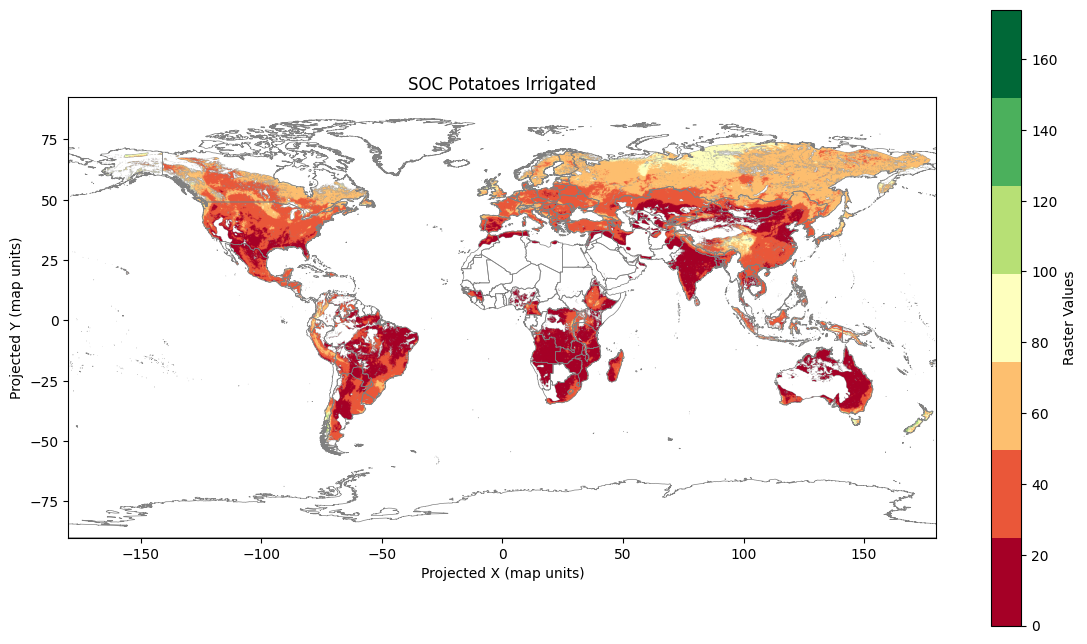

In [25]:
mp.plot_raster_on_world_extremes_cutoff(soc_pot_irr_raster, "SOC Potatoes Irrigated", quantiles=7,  perc_cutoff=0, raster_band=15, cmap="RdYlGn")

### Group of Rasters

In [26]:
soc_tom_irr_raster = "../LEAFs/SOC/rasters/Tomato_irr_2030y_SOC.tif"
soc_maize_irr_roff_raster = '../LEAFs/SOC/rasters/Maize_irr_roff_2030y_SOC.tif'
soc_soybean_irr_raster = '../LEAFs/SOC/rasters/Soybean_irr_2030y_SOC.tif'
soc_oilpalm_irr_raster = '../LEAFs/SOC/rasters/Oil palm_irr_2030y_SOC.tif'
soc_brdc_wtd_raster = "../LEAFs/SOC/rasters/BRDC_Warm temperate dry_2030y_SOC.tif"
soc_grass_raster = "../LEAFs/SOC/rasters/natural_grassland_cattle_avg_sheep_goat_2030y_SOC.tif"

Reprojecting to Natural Earth

In [27]:
import os

rasters = [
    soc_pot_irr_raster,
    soc_tom_irr_raster,
    soc_maize_irr_roff_raster,
    soc_soybean_irr_raster,
    soc_oilpalm_irr_raster,
    soc_brdc_wtd_raster,
    soc_grass_raster,
]

band = 15
dst_crs = "+proj=natearth"

for fp in rasters:
    da = rxr.open_rasterio(fp, masked=True)
    try:
        da_b = da.sel(band=band).squeeze()
    except Exception:
        da_b = da.isel(band=band - 1).squeeze()
    da_ne = da_b.rio.reproject(dst_crs, resampling=1)
    outfn = os.path.splitext(os.path.basename(fp))[0] + f"_band{band}_natear.tif"
    outfp = os.path.join("../paper", outfn)
    da_ne.rio.to_raster(outfp)
    print(f"Wrote: {outfp}")

Wrote: ../paper\Potato_irr_2030y_SOC_band15_natear.tif
Wrote: ../paper\Tomato_irr_2030y_SOC_band15_natear.tif
Wrote: ../paper\Maize_irr_roff_2030y_SOC_band15_natear.tif
Wrote: ../paper\Soybean_irr_2030y_SOC_band15_natear.tif
Wrote: ../paper\Oil palm_irr_2030y_SOC_band15_natear.tif
Wrote: ../paper\BRDC_Warm temperate dry_2030y_SOC_band15_natear.tif
Wrote: ../paper\natural_grassland_cattle_avg_sheep_goat_2030y_SOC_band15_natear.tif


Storing new paths

In [28]:
soc_tom_irr_raster_ne = "../paper/Tomato_irr_2030y_SOC_band15_natear.tif"
soc_maize_irr_roff_raster_ne =  '../paper/Maize_irr_roff_2030y_SOC_band15_natear.tif'
soc_soybean_irr_raster_ne = '../paper/Soybean_irr_2030y_SOC_band15_natear.tif'
soc_oilpalm_irr_raster_ne = '../paper/Oil palm_irr_2030y_SOC_band15_natear.tif'
soc_brdc_wtd_raster_ne = '../paper/BRDC_Warm temperate dry_2030y_SOC_band15_natear.tif'
soc_grass_raster_ne = '../paper/natural_grassland_cattle_avg_sheep_goat_2030y_SOC_band15_natear.tif'

Checking irrigated tomatoes to compare it with paper

In [29]:
soc_tom_irr = soc_er[(soc_er["flow_name"]=="Irrigated_Tomatoes")]

In [30]:
soc_tom_irr.sort_values(by=["cf"], ascending=False).head(10)

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,cf,cf_median,cf_std
25958,328.0,Huon Peninsula montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,141,"MULTIPOLYGON (((14110579.229 -616085.784, 1411...",Irrigated_Tomatoes,513.163391,475.152557,274.731537
19238,244.0,Eastern Panamanian montane forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,461,"MULTIPOLYGON (((-7529477.22 818268.547, -75297...",Irrigated_Tomatoes,474.791412,424.321289,271.640808
13958,176.0,Comoros forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Afrotropic,AF01,4,"MULTIPOLYGON (((4352376.706 -1440618.912, 4352...",Irrigated_Tomatoes,470.476746,470.476746,0.000000
56038,706.0,Sulawesi montane rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia,AU01,157,"MULTIPOLYGON (((11638542.212 -547151.325, 1163...",Irrigated_Tomatoes,450.603912,411.372589,251.128677
20038,254.0,Enriquillo wetlands,9.0,Flooded Grasslands & Savannas,Neotropic,NO09,580,"MULTIPOLYGON (((-6552040.314 2039394.279, -655...",Irrigated_Tomatoes,450.128357,450.128357,0.000000
18758,238.0,Eastern Himalayan broadleaf forests,4.0,Temperate Broadleaf & Mixed Forests,Indomalayan,IN04,306,"MULTIPOLYGON (((8471248.091 3065409.801, 84721...",Irrigated_Tomatoes,444.220795,401.046570,246.470627
57478,724.0,Talamancan montane forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,506,"MULTIPOLYGON (((-7797326.352 824105.308, -7797...",Irrigated_Tomatoes,412.762970,390.564545,236.765915
31478,398.0,Luzon tropical pine forests,3.0,Tropical & Subtropical Coniferous Forests,Indomalayan,IN03,303,"MULTIPOLYGON (((11566166.393 1998502.847, 1156...",Irrigated_Tomatoes,408.551025,433.948425,145.528381
8918,113.0,Cauca Valley montane forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,448,"MULTIPOLYGON (((-7298903.485 811268.372, -7298...",Irrigated_Tomatoes,390.481842,322.446899,289.656830
21078,267.0,Fiji tropical dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Oceania,NO02,635,"MULTIPOLYGON (((17029806.434 -1944012.738, 170...",Irrigated_Tomatoes,382.188965,329.566162,170.687683


<Axes: >

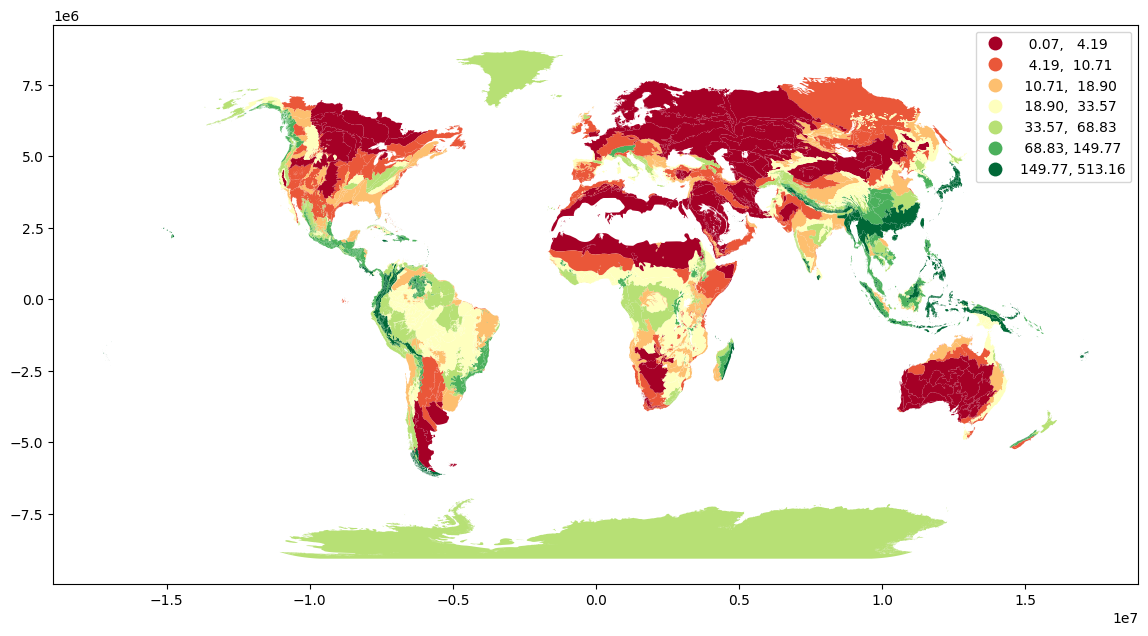

In [31]:
fig, ax = plt.subplots(figsize=(14, 8))

soc_tom_irr.plot(
    ax=ax,
    column="cf",
    legend=True,
    scheme="quantiles",
    k = 7,
    cmap="RdYlGn"
)

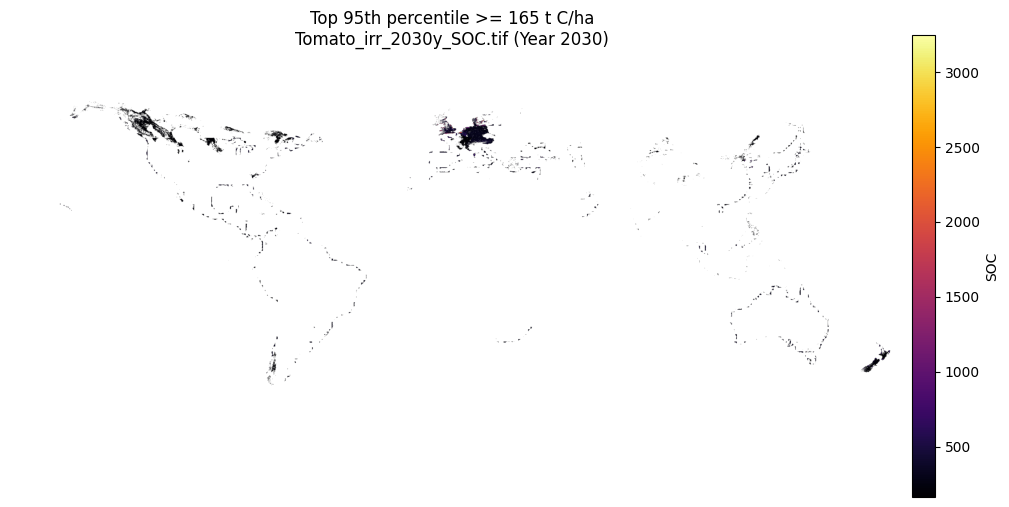

In [32]:
# plot only top 95th percentile values from soc_tom_irr_raster (use band 15 as in the later cell)
raster_fp = soc_tom_irr_raster
band = 15
perc_cutoff = 95

da = rxr.open_rasterio(raster_fp, masked=True)

# select band robustly (label or index)
try:
    da_b = da.sel(band=band).squeeze()
except Exception:
    da_b = da.isel(band=band - 1).squeeze()

arr = da_b.values
if np.ma.isMaskedArray(arr):
    arr = arr.filled(np.nan)
arr = arr.astype(float)

valid = np.isfinite(arr)
thr = np.nanpercentile(arr[valid], perc_cutoff)

arr_top95 = np.where(arr >= thr, arr, np.nan)

# plot
x0 = float(da_b["x"].values.min()); x1 = float(da_b["x"].values.max())
y0 = float(da_b["y"].values.min()); y1 = float(da_b["y"].values.max())
extent = (x0, x1, y0, y1)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(arr_top95, origin="upper", extent=extent, cmap="inferno")
ax.set_title(f"Top {perc_cutoff}th percentile >= {thr:.3g} t C/ha\n{raster_fp.split('/')[-1]} (Year {2015+band})")
ax.set_axis_off()
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02).set_label("SOC")
plt.show()

Plotting the rest of the rasters

In [33]:
importlib.reload(mp)

<module 'sbtn_leaf.map_plotting' from 'C:\\Users\\loyola\\OneDrive - World Wildlife Fund, Inc\\Documents\\203. Python projects\\SBTN_Test\\src\\sbtn_leaf\\map_plotting.py'>

In [34]:
q_breaks = [0,10,30,50,70,90,110,200]

Raster has 2,127,866 unique values. Min: 16.71. Max: 164.84
Using quantile edges


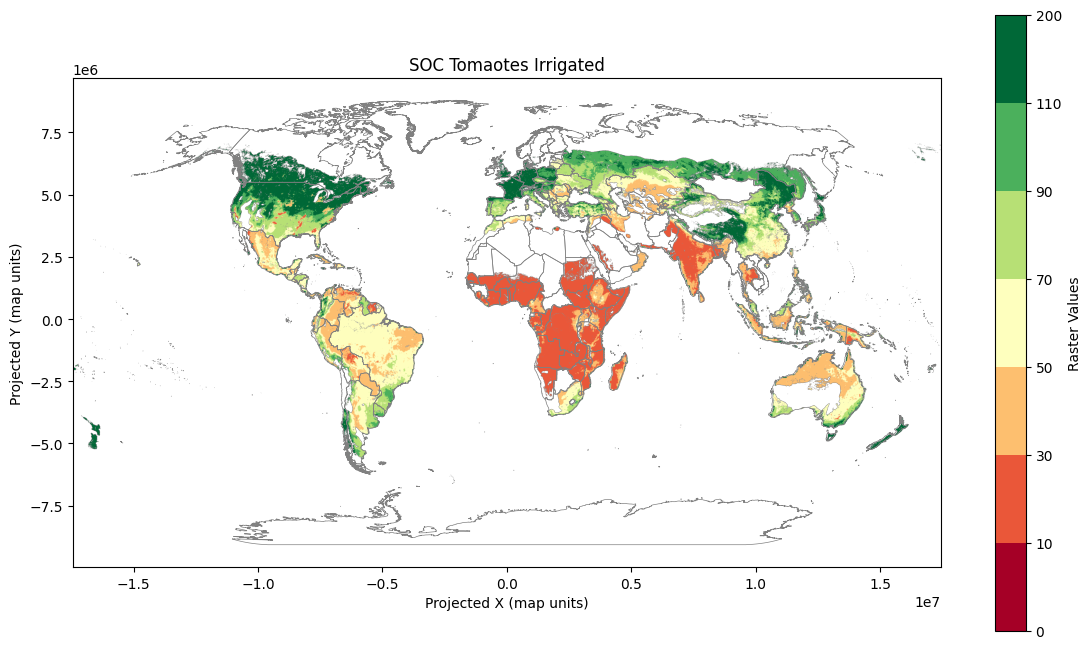

In [35]:
mp.plot_raster_on_world_extremes_cutoff(soc_tom_irr_raster_ne, "SOC Tomaotes Irrigated", quantiles=q_breaks,  perc_cutoff=5,  cmap="RdYlGn")

Raster has 1,372,681 unique values. Min: 9.87. Max: 63.60
Using quantile edges


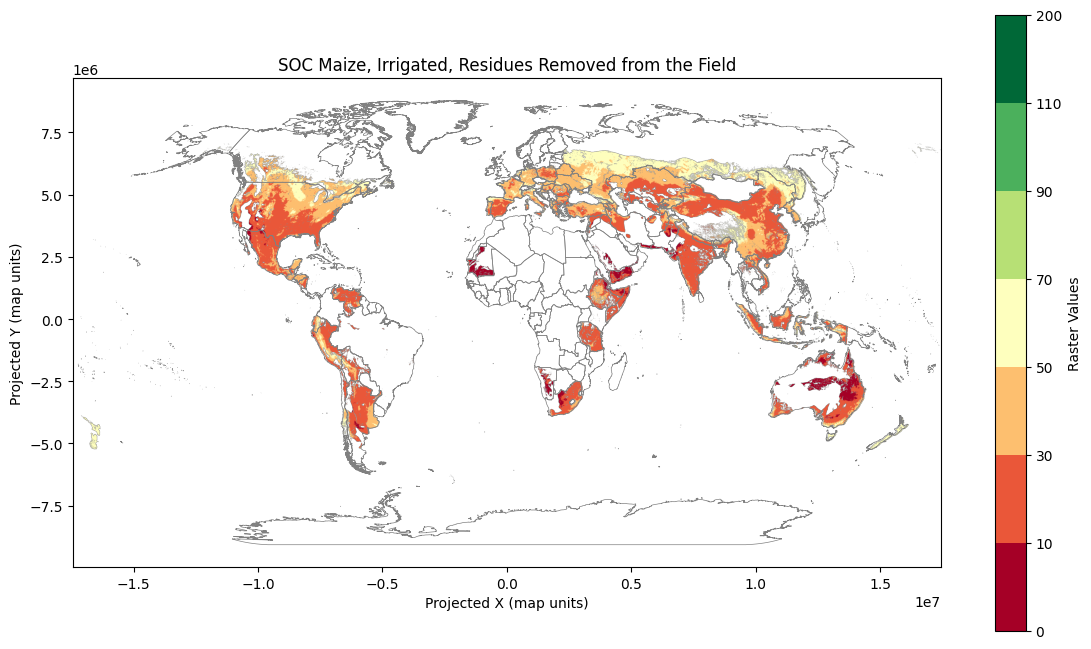

In [36]:
mp.plot_raster_on_world_extremes_cutoff(soc_maize_irr_roff_raster_ne, "SOC Maize, Irrigated, Residues Removed from the Field", quantiles=q_breaks,  perc_cutoff=5,  cmap="RdYlGn")

Raster has 1,472,991 unique values. Min: 15.82. Max: 71.04
Using quantile edges


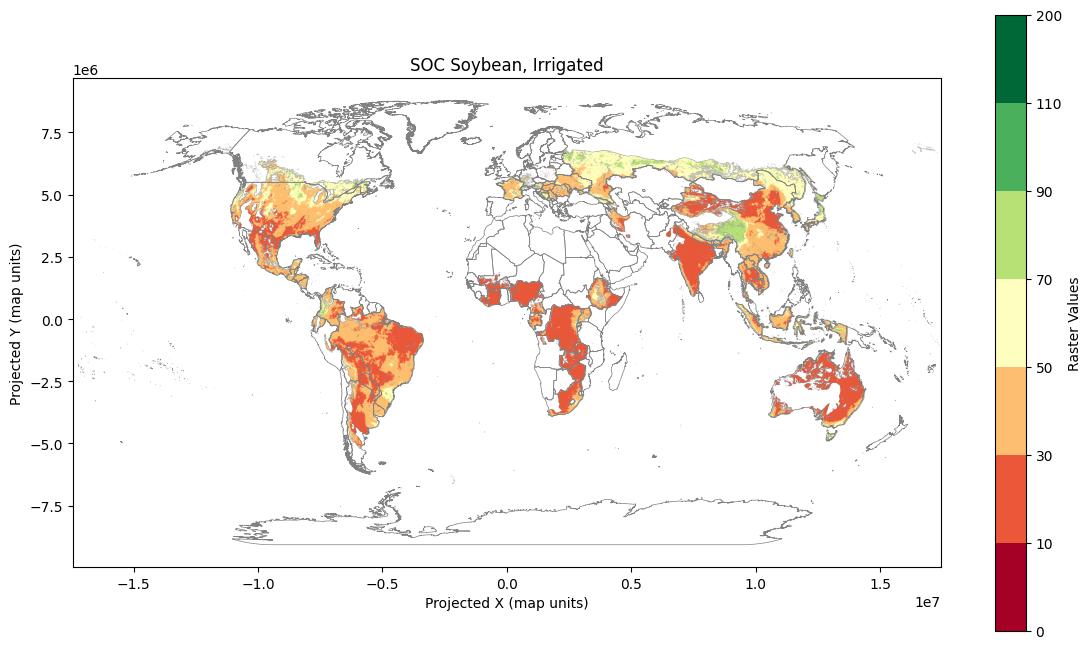

In [37]:
mp.plot_raster_on_world_extremes_cutoff(soc_soybean_irr_raster_ne, "SOC Soybean, Irrigated", quantiles=q_breaks,  perc_cutoff=5, raster_band=1, cmap="RdYlGn")

Raster has 6,694 unique values. Min: 10.13. Max: 43.99
Using quantile edges


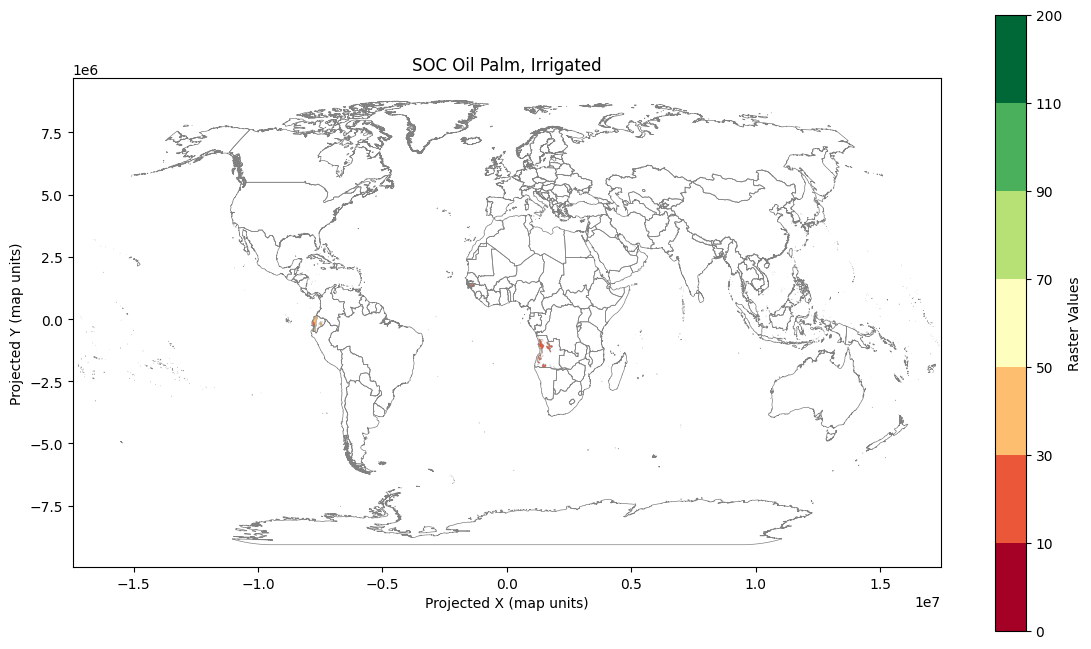

In [38]:
mp.plot_raster_on_world_extremes_cutoff(soc_oilpalm_irr_raster_ne, "SOC Oil Palm, Irrigated", quantiles=q_breaks,  perc_cutoff=5, raster_band=1, cmap="RdYlGn")

Raster has 531,496 unique values. Min: 37.44. Max: 96.68
Using quantile edges


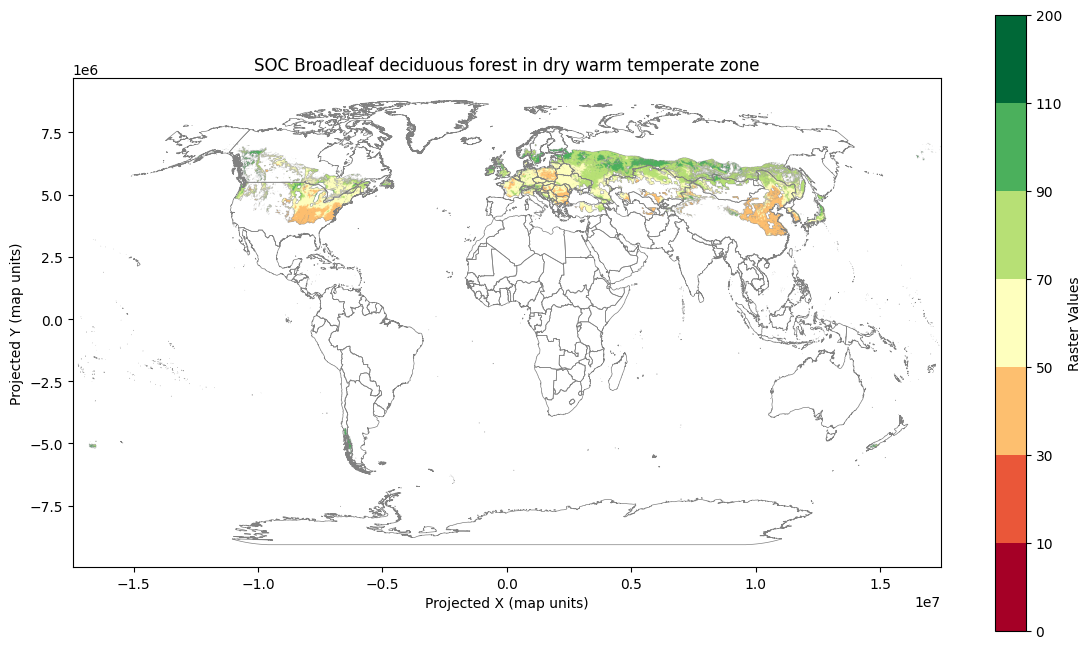

In [39]:
mp.plot_raster_on_world_extremes_cutoff(soc_brdc_wtd_raster_ne, "SOC Broadleaf deciduous forest in dry warm temperate zone", quantiles=q_breaks,  perc_cutoff=5, cmap="RdYlGn")

Raster has 2,217,672 unique values. Min: 28.41. Max: 96.30
Using quantile edges


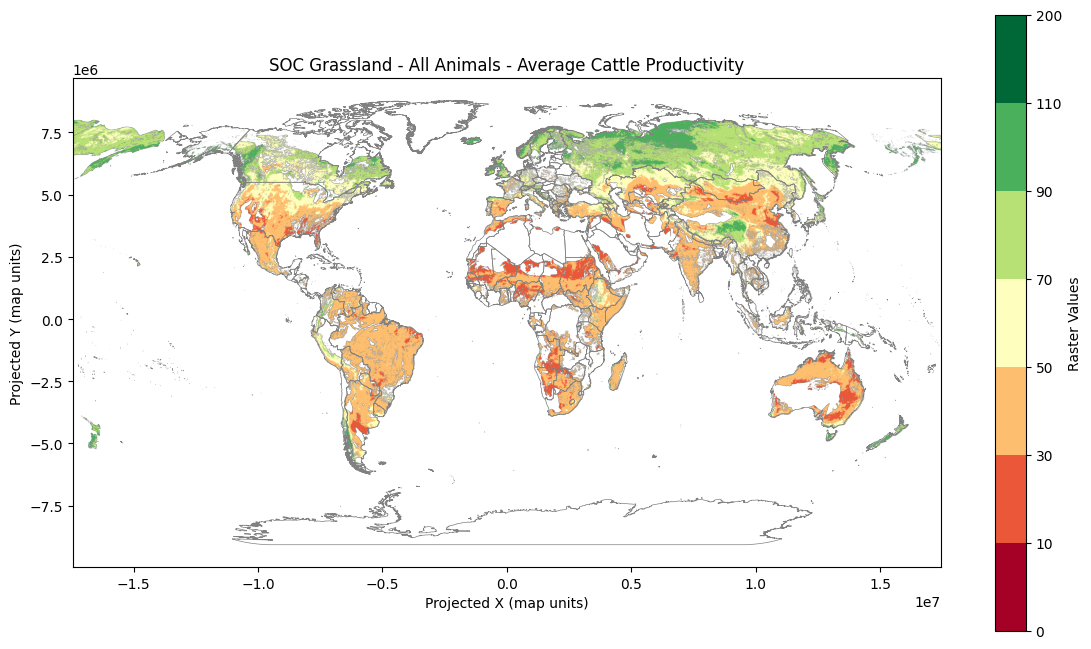

In [40]:
mp.plot_raster_on_world_extremes_cutoff(soc_grass_raster_ne, "SOC Grassland - All Animals - Average Cattle Productivity", quantiles=q_breaks,  perc_cutoff=5, cmap="RdYlGn")

### SOC Evolution for Nearctic
Plotting evolution of SOC for the same crops in the nearctic

#### Loading shapefile with Nearctic

In [41]:
er_shp = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")
er_na_shp = er_shp[er_shp['REALM']=='Nearctic']

<Axes: >

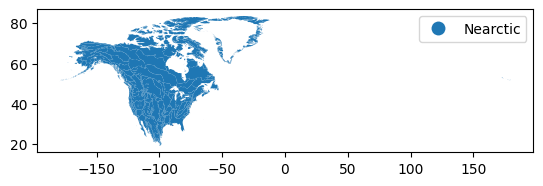

In [42]:
er_na_shp.plot(column="REALM", legend = True)

#### Clipping rasters

Tomatoe

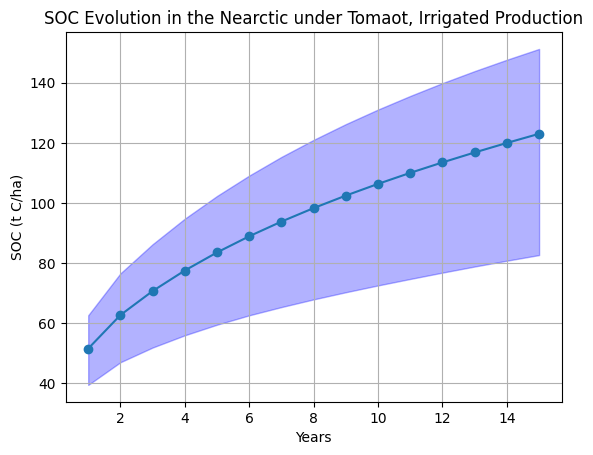

In [43]:
da = rxr.open_rasterio(soc_tom_irr_raster, masked=True)  # dims like (band, y, x)

# make sure CRS matches
shp = er_na_shp.to_crs(da.rio.crs)

# clip
da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

# 3) rename the band‐axis to “time”
show_iq = True
xlabel = 'Years'
ylabel = 'SOC (t C/ha)'
title = 'SOC Evolution in the Nearctic under Tomaot, Irrigated Production'

da = da_clip.rename({da_clip.dims[0]: "time"})

# 4) assign integer time steps 1…N (or real dates)
duration = da.sizes["time"]
da = da.assign_coords(time = ("time", np.arange(1, duration+1)))

# Global mean
ts_mean  = da.mean(dim=["x","y"], skipna=True)              # shape = (time,)
if show_iq:
    q1 = da.quantile(q=0.25, dim=["x","y"], skipna=True)
    q3 = da.quantile(q=0.75, dim=["x","y"], skipna=True)                   

# Plot SOC
plt.figure()
plt.plot(ts_mean["time"].values, ts_mean.values, marker='o')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True, "major")

if show_iq:
    plt.fill_between(ts_mean["time"].values, q1.values, q3.values, color='blue', alpha=0.3, label='IQR')

plt.show()

### Stack practices

Tomatoe

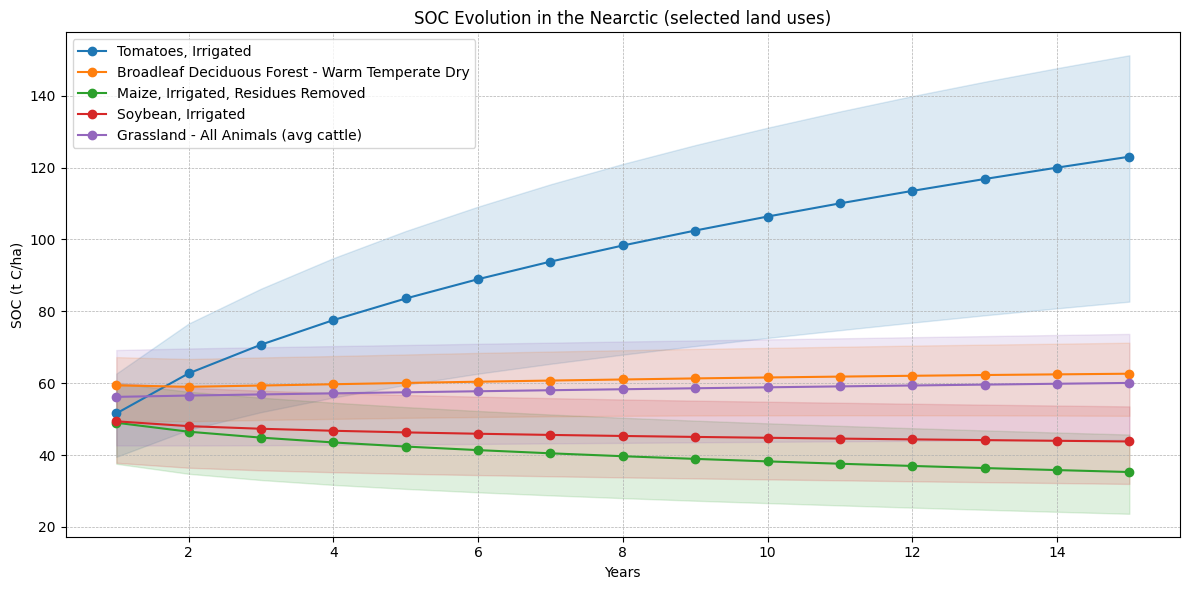

In [44]:
# Single plot with 4 SOC evolution lines (Nearctic)
raster_info = [
    (soc_tom_irr_raster, "Tomatoes, Irrigated"),
    (soc_brdc_wtd_raster, "Broadleaf Deciduous Forest - Warm Temperate Dry"),
    (soc_maize_irr_roff_raster, "Maize, Irrigated, Residues Removed"),
    (soc_soybean_irr_raster, "Soybean, Irrigated"),
    (soc_grass_raster, "Grassland - All Animals (avg cattle)"),
]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["C0", "C1", "C2", "C3", "C4"]

for i, (fp, title) in enumerate(raster_info):
    da = rxr.open_rasterio(fp, masked=True)

    # ensure CRS matches and clip to Nearctic shape
    shp = er_na_shp.to_crs(da.rio.crs)
    da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

    # rename first dim to "time" and assign integer time coordinates
    da_t = da_clip.rename({da_clip.dims[0]: "time"})
    duration = da_t.sizes["time"]
    da_t = da_t.assign_coords(time=("time", np.arange(1, duration + 1)))

    # global mean time series and IQR for spatial variability
    ts_mean = da_t.mean(dim=["x", "y"], skipna=True).squeeze()
    q1 = da_t.quantile(q=0.25, dim=["x", "y"], skipna=True).squeeze()
    q3 = da_t.quantile(q=0.75, dim=["x", "y"], skipna=True).squeeze()

    tvals = ts_mean["time"].values
    ax.plot(tvals, ts_mean.values, marker="o", color=colors[i], label=title)
    if q1.size and q3.size:
        ax.fill_between(tvals, q1.values, q3.values, color=colors[i], alpha=0.15)

ax.set_xlabel("Years")
ax.set_ylabel("SOC (t C/ha)")
ax.set_title("SOC Evolution in the Nearctic (selected land uses)")
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


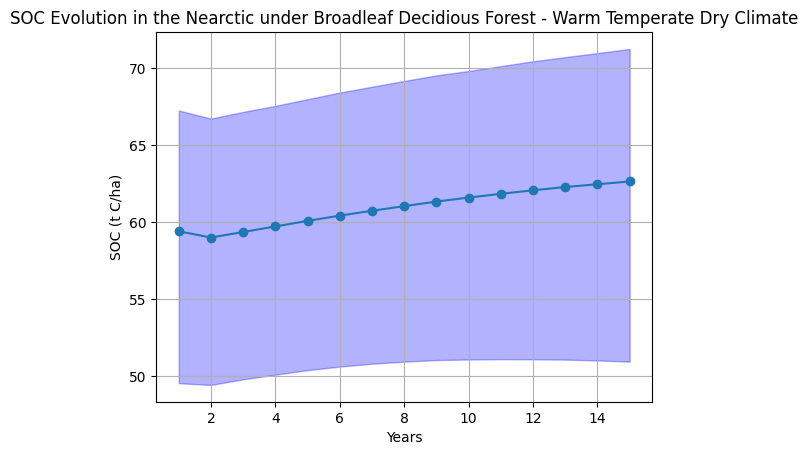

In [45]:
da = rxr.open_rasterio(soc_brdc_wtd_raster, masked=True)  # dims like (band, y, x)

# make sure CRS matches
shp = er_na_shp.to_crs(da.rio.crs)

# clip
da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

# 3) rename the band‐axis to “time”
show_iq = True
xlabel = 'Years'
ylabel = 'SOC (t C/ha)'
title = 'SOC Evolution in the Nearctic under Broadleaf Decidious Forest - Warm Temperate Dry Climate'

da = da_clip.rename({da_clip.dims[0]: "time"})

# 4) assign integer time steps 1…N (or real dates)
duration = da.sizes["time"]
da = da.assign_coords(time = ("time", np.arange(1, duration+1)))

# Global mean
ts_mean  = da.mean(dim=["x","y"], skipna=True)              # shape = (time,)
if show_iq:
    q1 = da.quantile(q=0.25, dim=["x","y"], skipna=True)
    q3 = da.quantile(q=0.75, dim=["x","y"], skipna=True)                   

# Plot SOC
plt.figure()
plt.plot(ts_mean["time"].values, ts_mean.values, marker='o')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True, "major")

if show_iq:
    plt.fill_between(ts_mean["time"].values, q1.values, q3.values, color='blue', alpha=0.3, label='IQR')

plt.show()

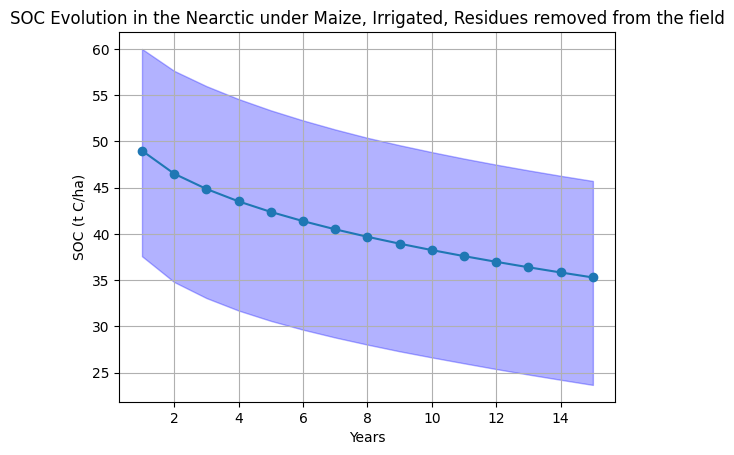

In [46]:
da = rxr.open_rasterio(soc_maize_irr_roff_raster, masked=True)  # dims like (band, y, x)

# make sure CRS matches
shp = er_na_shp.to_crs(da.rio.crs)

# clip
da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

# 3) rename the band‐axis to “time”
show_iq = True
xlabel = 'Years'
ylabel = 'SOC (t C/ha)'
title = 'SOC Evolution in the Nearctic under Maize, Irrigated, Residues removed from the field'

da = da_clip.rename({da_clip.dims[0]: "time"})

# 4) assign integer time steps 1…N (or real dates)
duration = da.sizes["time"]
da = da.assign_coords(time = ("time", np.arange(1, duration+1)))

# Global mean
ts_mean  = da.mean(dim=["x","y"], skipna=True)              # shape = (time,)
if show_iq:
    q1 = da.quantile(q=0.25, dim=["x","y"], skipna=True)
    q3 = da.quantile(q=0.75, dim=["x","y"], skipna=True)                   

# Plot SOC
plt.figure()
plt.plot(ts_mean["time"].values, ts_mean.values, marker='o')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True, "major")

if show_iq:
    plt.fill_between(ts_mean["time"].values, q1.values, q3.values, color='blue', alpha=0.3, label='IQR')

plt.show()

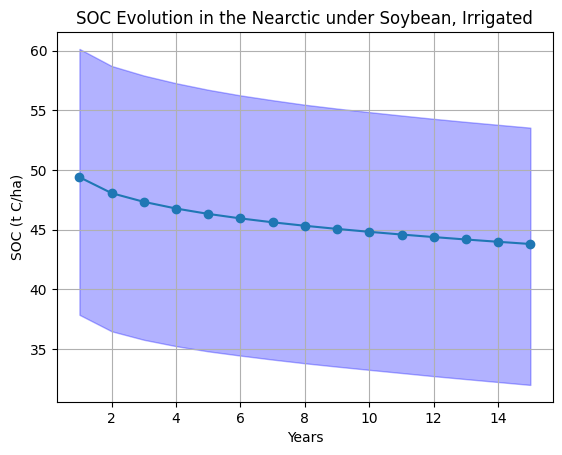

In [47]:
da = rxr.open_rasterio(soc_soybean_irr_raster, masked=True)  # dims like (band, y, x)

# make sure CRS matches
shp = er_na_shp.to_crs(da.rio.crs)

# clip
da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

# 3) rename the band‐axis to “time”
show_iq = True
xlabel = 'Years'
ylabel = 'SOC (t C/ha)'
title = 'SOC Evolution in the Nearctic under Soybean, Irrigated'

da = da_clip.rename({da_clip.dims[0]: "time"})

# 4) assign integer time steps 1…N (or real dates)
duration = da.sizes["time"]
da = da.assign_coords(time = ("time", np.arange(1, duration+1)))

# Global mean
ts_mean  = da.mean(dim=["x","y"], skipna=True)              # shape = (time,)
if show_iq:
    q1 = da.quantile(q=0.25, dim=["x","y"], skipna=True)
    q3 = da.quantile(q=0.75, dim=["x","y"], skipna=True)                   

# Plot SOC
plt.figure()
plt.plot(ts_mean["time"].values, ts_mean.values, marker='o')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True, "major")

if show_iq:
    plt.fill_between(ts_mean["time"].values, q1.values, q3.values, color='blue', alpha=0.3, label='IQR')

plt.show()

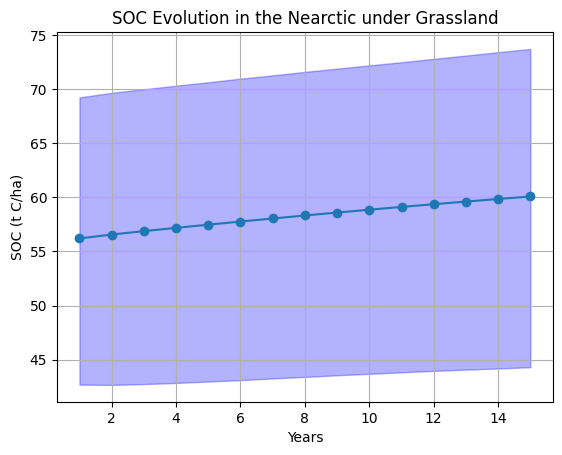

In [48]:
da = rxr.open_rasterio(soc_grass_raster, masked=True)  # dims like (band, y, x)

# make sure CRS matches
shp = er_na_shp.to_crs(da.rio.crs)

# clip
da_clip = da.rio.clip(shp.geometry, shp.crs, drop=True)

# 3) rename the band‐axis to “time”
show_iq = True
xlabel = 'Years'
ylabel = 'SOC (t C/ha)'
title = 'SOC Evolution in the Nearctic under Grassland'

da = da_clip.rename({da_clip.dims[0]: "time"})

# 4) assign integer time steps 1…N (or real dates)
duration = da.sizes["time"]
da = da.assign_coords(time = ("time", np.arange(1, duration+1)))

# Global mean
ts_mean  = da.mean(dim=["x","y"], skipna=True)              # shape = (time,)
if show_iq:
    q1 = da.quantile(q=0.25, dim=["x","y"], skipna=True)
    q3 = da.quantile(q=0.75, dim=["x","y"], skipna=True)                   

# Plot SOC
plt.figure()
plt.plot(ts_mean["time"].values, ts_mean.values, marker='o')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True, "major")

if show_iq:
    plt.fill_between(ts_mean["time"].values, q1.values, q3.values, color='blue', alpha=0.3, label='IQR')

plt.show()

## Checking tomatoes, potatoes, wheat

### FAOSTAT

Loading data

In [49]:
yields = pd.read_csv("../data/crops/fao_crop_yields_1423.csv", sep=";")

Extracting needed commodities info

In [50]:
yields_tomato = yields[yields["Item"]=="Tomatoes"]
yields_potato = yields[yields["Item"]=="Potatoes"]
yields_maize = yields[yields["Item"]=="Maize (corn)"]

In [51]:
data_tom = yields_tomato["avg_yield_1423"] / 1000.0
logdata_tom = np.log10(data_tom)
tom_global_avg = data_tom.mean()
tom_us_avg = yields_tomato[yields_tomato["Area"]=="United States of America"]["avg_yield_1423"].item()/1000

data_pot = yields_potato["avg_yield_1423"] / 1000.0
logdata_pot = np.log10(data_pot)
pot_global_avg = data_pot.mean()
pot_us_avg = yields_potato[yields_potato["Area"]=="United States of America"]["avg_yield_1423"].item()/1000

data_maize = yields_maize["avg_yield_1423"] / 1000.0
logdata_maize = np.log10(data_maize)
maize_global_avg = data_maize.mean()
maize_us_avg = yields_maize[yields_maize["Area"]=="United States of America"]["avg_yield_1423"].item()/1000

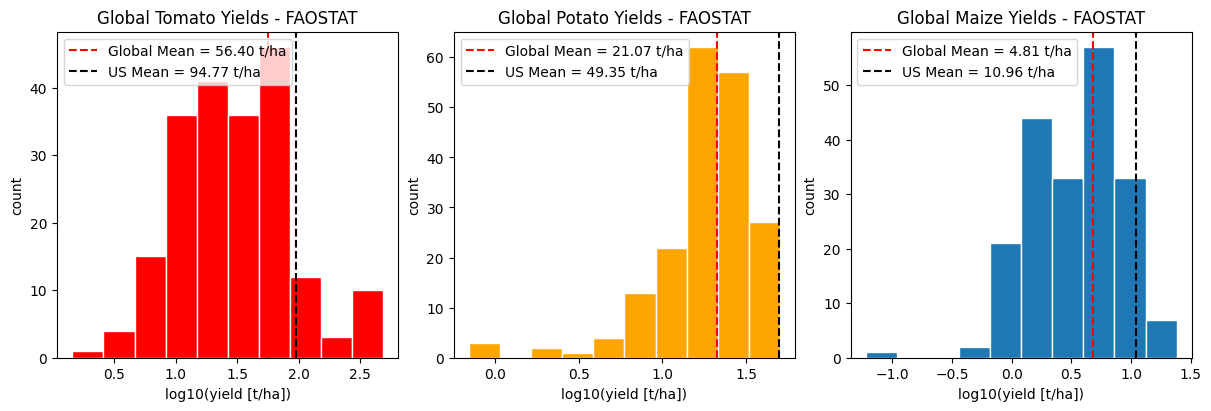

In [52]:
fig, ax = plt.subplots(ncols=3, layout="constrained", figsize = (12,4))

ax[0].hist(logdata_tom, bins=10, edgecolor="white", color="red")
ax[0].axvline(np.log10(tom_global_avg), color="red", linestyle="--", label=f"Global Mean = {tom_global_avg:.2f} t/ha")
ax[0].axvline(np.log10(tom_us_avg), color="black", linestyle="--", label=f"US Mean = {tom_us_avg:.2f} t/ha")
ax[0].set_xlabel("log10(yield [t/ha])")
ax[0].set_ylabel("count")
ax[0].set_title("Global Tomato Yields - FAOSTAT")
ax[0].legend()

ax[1].hist(logdata_pot, bins=10, edgecolor="white", color = "orange")
ax[1].axvline(np.log10(pot_global_avg), color="red", linestyle="--", label=f"Global Mean = {pot_global_avg:.2f} t/ha")
ax[1].axvline(np.log10(pot_us_avg), color="black", linestyle="--", label=f"US Mean = {pot_us_avg:.2f} t/ha")
ax[1].set_xlabel("log10(yield [t/ha])")
ax[1].set_ylabel("count")
ax[1].set_title("Global Potato Yields - FAOSTAT")
ax[1].legend()

ax[2].hist(logdata_maize, bins=10, edgecolor="white")
ax[2].axvline(np.log10(maize_global_avg), color="red", linestyle="--", label=f"Global Mean = {maize_global_avg:.2f} t/ha")
ax[2].axvline(np.log10(maize_us_avg), color="black", linestyle="--", label=f"US Mean = {maize_us_avg:.2f} t/ha")
ax[2].set_xlabel("log10(yield [t/ha])")
ax[2].set_ylabel("count")
ax[2].set_title("Global Maize Yields - FAOSTAT")
ax[2].legend()

### SPAM
Checking SPAM yields

In [53]:
tom_spam_a = "../data/crops/spam2020V2r0_global_yield/spam2020_V2r0_global_Y_TOMA_A.tif"
pot_spam_a = "../data/crops/spam2020V2r0_global_yield/spam2020_V2r0_global_Y_POTA_A.tif"
maize_spam_a = "../data/crops/spam2020V2r0_global_yield/spam2020_V2r0_global_Y_MAIZ_A.tif"

Raster has 4,905 unique values. Min: 0.00. Max: 1,108.10
Using quantiles
All positives route (quantiles)


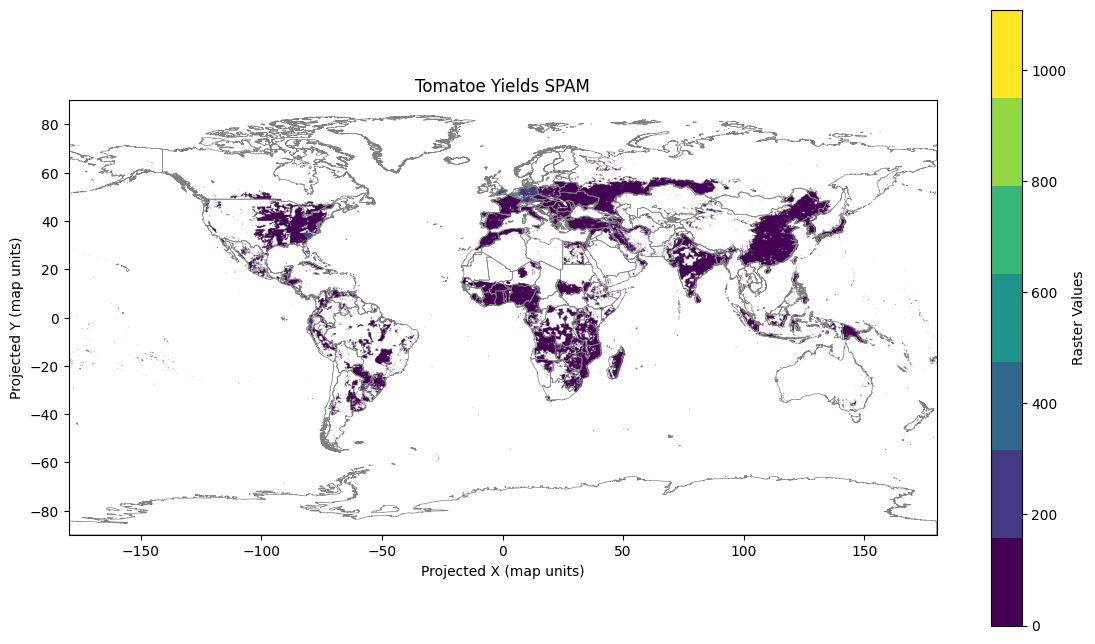

In [54]:
mp.plot_raster_on_world_extremes_cutoff(tom_spam_a, "Tomatoe Yields SPAM", quantiles=7, perc_cutoff=0)

So clearly some very high yields in some places...

Plotting withing 5-95% quantila range

Raster has 1,056 unique values. Min: 1.00. Max: 106.50
Using quantiles
All positives route (quantiles)


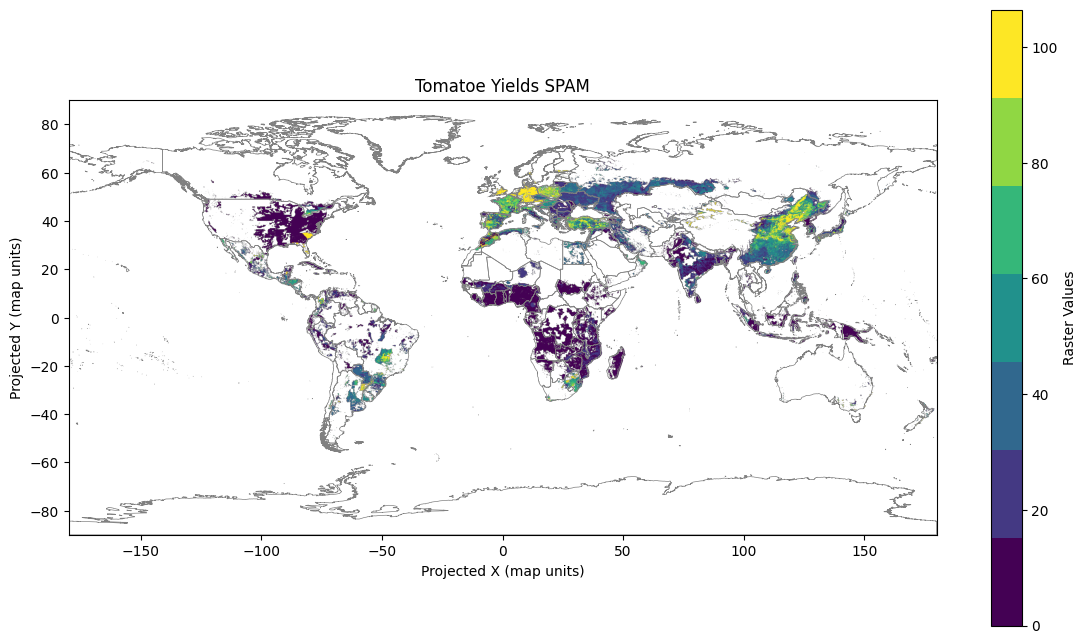

In [55]:
mp.plot_raster_on_world_extremes_cutoff(tom_spam_a, "Tomatoe Yields SPAM", quantiles=7, perc_cutoff=5)

Makes it way better.

Where are those top 5%?

Raster has 3,214 unique values. Min: 169.10. Max: 1,108.10
Using quantiles
All positives route (quantiles)


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'Yields above 97.5% (169.1 ton/ha)'}, xlabel='Projected X (map units)', ylabel='Projected Y (map units)'>)

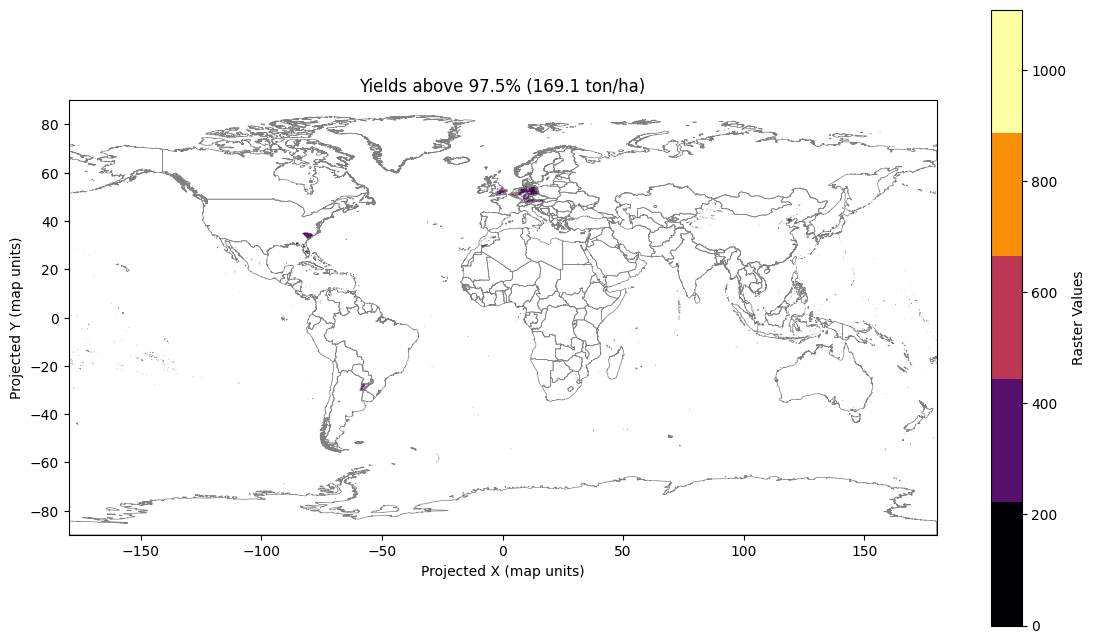

In [57]:
# plot only top 95th percentile values from soc_tom_irr_raster
raster_fp = tom_spam_a
band = 1
perc_cutoff = 97.5

da = rxr.open_rasterio(raster_fp, masked=True)

# select band robustly (label or index)
try:
    da_b = da.sel(band=band).squeeze()
except Exception:
    da_b = da.isel(band=band - 1).squeeze()

# compute threshold from values (ignoring NaNs)
thr = float(da_b.quantile(perc_cutoff / 100.0, skipna=True))

# keep only top values
da_top = da_b.where(da_b >= thr)

mp.plot_da_on_world_extremes_cutoff(da_top, f"Yields above {perc_cutoff}% ({thr:.1f} ton/ha)", perc_cutoff=0, cmap="inferno", quantiles=5)

#### Histograms

In [58]:
tom_spam_a_yields = rxr.open_rasterio(tom_spam_a, masked=True).squeeze().values
pot_spam_a_yields = rxr.open_rasterio(pot_spam_a, masked=True).squeeze().values
maize_spam_a_yields = rxr.open_rasterio(maize_spam_a, masked=True).squeeze().values

Eliminating nans

In [59]:
tom_spam_a_yields = tom_spam_a_yields[(np.isfinite(tom_spam_a_yields)) & (tom_spam_a_yields>0)]
pot_spam_a_yields = pot_spam_a_yields[np.isfinite(pot_spam_a_yields) & (pot_spam_a_yields>0)]
maize_spam_a_yields = maize_spam_a_yields[np.isfinite(maize_spam_a_yields) & (maize_spam_a_yields>0)]

log10 transform & global mean

In [60]:
logdata_tom_spam = np.log10(tom_spam_a_yields)
tom_global_avg_spam = tom_spam_a_yields.mean()
tom_global_std_spam = tom_spam_a_yields.std()

logdata_pot_spam = np.log10(pot_spam_a_yields)
pot_global_avg_spam = pot_spam_a_yields.mean()
pot_global_std_spam = pot_spam_a_yields.std()

logdata_maize_spam = np.log10(maize_spam_a_yields)
maize_global_avg_spam = maize_spam_a_yields.mean()
maize_global_std_spam = maize_spam_a_yields.std()

Getting yields for US...

In [61]:
# Loading country maps
country_gdf = gpd.read_file("../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp")

In [62]:
us_gdf = country_gdf[country_gdf["ADM0_NAME"]=="United States of America"]

Clipping...

In [63]:
da_tom_spam = rxr.open_rasterio(tom_spam_a, masked=True)
da_pot_spam = rxr.open_rasterio(pot_spam_a, masked=True)
da_maize_spam = rxr.open_rasterio(maize_spam_a, masked=True)

# make sure CRS matches
shp = us_gdf.to_crs(da.rio.crs)

# clip
da_tom_spam_us = da_tom_spam.rio.clip(shp.geometry, shp.crs, drop=True)
da_pot_spam_us = da_pot_spam.rio.clip(shp.geometry, shp.crs, drop=True)
da_maize_spam_us = da_maize_spam.rio.clip(shp.geometry, shp.crs, drop=True)

Calcualting US Averages

In [66]:
tom_spam_us_vals = da_tom_spam_us.squeeze().values
pot_spam_us_vals = da_pot_spam_us.squeeze().values
maize_spam_us_vals = da_maize_spam_us.squeeze().values

tom_spam_us_vals = tom_spam_us_vals[np.isfinite(tom_spam_us_vals) & (tom_spam_us_vals>0)]
pot_spam_us_vals = pot_spam_us_vals[np.isfinite(pot_spam_us_vals) & (pot_spam_us_vals>0)]
maize_spam_us_vals = maize_spam_us_vals[np.isfinite(maize_spam_us_vals) & (maize_spam_us_vals>0)]

tom_spam_us_avg = tom_spam_us_vals.mean()
pot_spam_us_avg = pot_spam_us_vals.mean()
maize_spam_us_avg = maize_spam_us_vals.mean()

Finally histograms

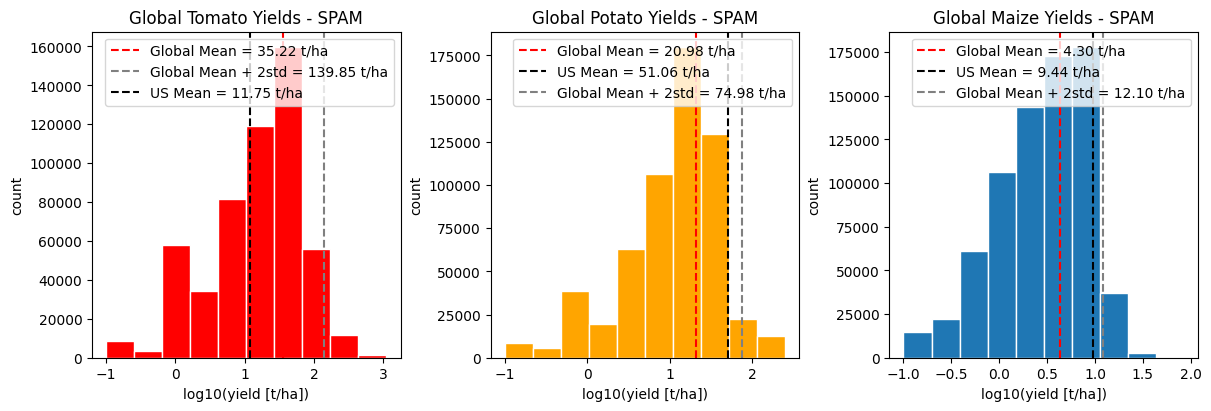

In [67]:
fig, ax = plt.subplots(ncols=3, layout="constrained", figsize = (12,4))

ax[0].hist(logdata_tom_spam, bins=10, edgecolor="white", color="red")
ax[0].axvline(np.log10(tom_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {tom_global_avg_spam:.2f} t/ha")
ax[0].axvline(np.log10(tom_global_avg_spam+2*tom_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {tom_global_avg_spam+2*tom_global_std_spam:.2f} t/ha")
ax[0].axvline(np.log10(tom_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {tom_spam_us_avg:.2f} t/ha")
ax[0].set_xlabel("log10(yield [t/ha])")
ax[0].set_ylabel("count")
ax[0].set_title("Global Tomato Yields - SPAM")
ax[0].legend()

ax[1].hist(logdata_pot_spam, bins=10, edgecolor="white", color = "orange")
ax[1].axvline(np.log10(pot_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {pot_global_avg_spam:.2f} t/ha")
ax[1].axvline(np.log10(pot_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {pot_spam_us_avg:.2f} t/ha")
ax[1].axvline(np.log10(pot_global_avg_spam+2*pot_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {pot_global_avg_spam+2*pot_global_std_spam:.2f} t/ha")
ax[1].set_xlabel("log10(yield [t/ha])")
ax[1].set_ylabel("count")
ax[1].set_title("Global Potato Yields - SPAM")
ax[1].legend()

ax[2].hist(logdata_maize_spam, bins=10, edgecolor="white")
ax[2].axvline(np.log10(maize_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {maize_global_avg_spam:.2f} t/ha")
ax[2].axvline(np.log10(maize_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {maize_spam_us_avg:.2f} t/ha")
ax[2].axvline(np.log10(maize_global_avg_spam+2*maize_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {maize_global_avg_spam+2*maize_global_std_spam:.2f} t/ha")
ax[2].set_xlabel("log10(yield [t/ha])")
ax[2].set_ylabel("count")
ax[2].set_title("Global Maize Yields - SPAM")
ax[2].legend()

There are clearly some outlers, with some yields over 1000 ton per hectare for tomatoes, and some yields on the very small side for all crops...
Also curious than the US average is lower than the global average for tomatoes, which could be due to the outliers, as this doesn't happen with the other crops

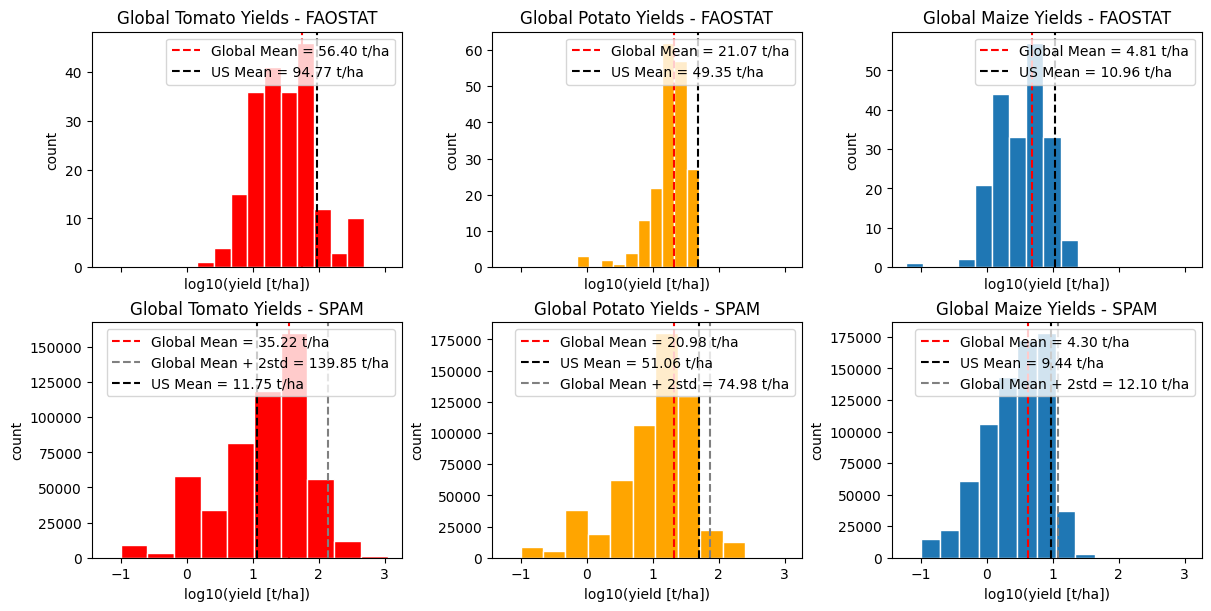

In [71]:
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained", figsize = (12,6), sharex=True)

ax[0,0].hist(logdata_tom, bins=10, edgecolor="white", color="red")
ax[0,0].axvline(np.log10(tom_global_avg), color="red", linestyle="--", label=f"Global Mean = {tom_global_avg:.2f} t/ha")
ax[0,0].axvline(np.log10(tom_us_avg), color="black", linestyle="--", label=f"US Mean = {tom_us_avg:.2f} t/ha")
ax[0,0].set_xlabel("log10(yield [t/ha])")
ax[0,0].set_ylabel("count")
ax[0,0].set_title("Global Tomato Yields - FAOSTAT")
ax[0,0].legend()

ax[0,1].hist(logdata_pot, bins=10, edgecolor="white", color = "orange")
ax[0,1].axvline(np.log10(pot_global_avg), color="red", linestyle="--", label=f"Global Mean = {pot_global_avg:.2f} t/ha")
ax[0,1].axvline(np.log10(pot_us_avg), color="black", linestyle="--", label=f"US Mean = {pot_us_avg:.2f} t/ha")
ax[0,1].set_xlabel("log10(yield [t/ha])")
ax[0,1].set_ylabel("count")
ax[0,1].set_title("Global Potato Yields - FAOSTAT")
ax[0,1].legend()

ax[0,2].hist(logdata_maize, bins=10, edgecolor="white")
ax[0,2].axvline(np.log10(maize_global_avg), color="red", linestyle="--", label=f"Global Mean = {maize_global_avg:.2f} t/ha")
ax[0,2].axvline(np.log10(maize_us_avg), color="black", linestyle="--", label=f"US Mean = {maize_us_avg:.2f} t/ha")
ax[0,2].set_xlabel("log10(yield [t/ha])")
ax[0,2].set_ylabel("count")
ax[0,2].set_title("Global Maize Yields - FAOSTAT")
ax[0,2].legend()

ax[1,0].hist(logdata_tom_spam, bins=10, edgecolor="white", color="red")
ax[1,0].axvline(np.log10(tom_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {tom_global_avg_spam:.2f} t/ha")
ax[1,0].axvline(np.log10(tom_global_avg_spam+2*tom_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {tom_global_avg_spam+2*tom_global_std_spam:.2f} t/ha")
ax[1,0].axvline(np.log10(tom_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {tom_spam_us_avg:.2f} t/ha")
ax[1,0].set_xlabel("log10(yield [t/ha])")
ax[1,0].set_ylabel("count")
ax[1,0].set_title("Global Tomato Yields - SPAM")
ax[1,0].legend()

ax[1,1].hist(logdata_pot_spam, bins=10, edgecolor="white", color = "orange")
ax[1,1].axvline(np.log10(pot_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {pot_global_avg_spam:.2f} t/ha")
ax[1,1].axvline(np.log10(pot_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {pot_spam_us_avg:.2f} t/ha")
ax[1,1].axvline(np.log10(pot_global_avg_spam+2*pot_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {pot_global_avg_spam+2*pot_global_std_spam:.2f} t/ha")
ax[1,1].set_xlabel("log10(yield [t/ha])")
ax[1,1].set_ylabel("count")
ax[1,1].set_title("Global Potato Yields - SPAM")
ax[1,1].legend()

ax[1,2].hist(logdata_maize_spam, bins=10, edgecolor="white")
ax[1,2].axvline(np.log10(maize_global_avg_spam), color="red", linestyle="--", label=f"Global Mean = {maize_global_avg_spam:.2f} t/ha")
ax[1,2].axvline(np.log10(maize_spam_us_avg), color="black", linestyle="--", label=f"US Mean = {maize_spam_us_avg:.2f} t/ha")
ax[1,2].axvline(np.log10(maize_global_avg_spam+2*maize_global_std_spam), color="grey", linestyle="--", label=f"Global Mean + 2std = {maize_global_avg_spam+2*maize_global_std_spam:.2f} t/ha")
ax[1,2].set_xlabel("log10(yield [t/ha])")
ax[1,2].set_ylabel("count")
ax[1,2].set_title("Global Maize Yields - SPAM")
ax[1,2].legend()

plt.show()

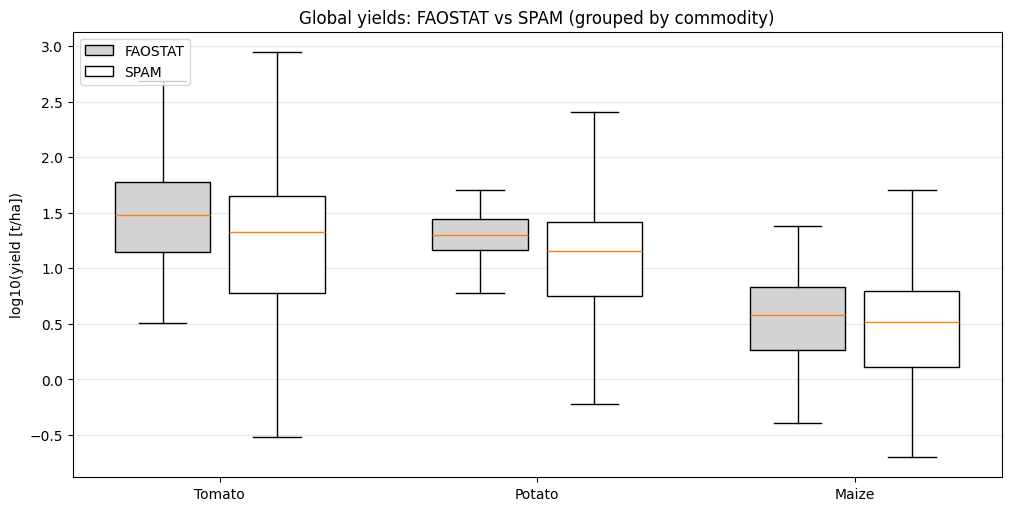

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Pack your already-computed log10 yield arrays ----
# (these should be 1D arrays of log10(yield[t/ha]) values)
commodities = ["Tomato", "Potato", "Maize"]

fao_data  = [logdata_tom,      logdata_pot,      logdata_maize]
spam_data = [logdata_tom_spam, logdata_pot_spam, logdata_maize_spam]

# ---- Build grouped boxplots (FAO vs SPAM per commodity) ----
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")

x = np.arange(len(commodities))
offset = 0.18
width = 0.30

pos_fao  = x - offset
pos_spam = x + offset

bp_fao = ax.boxplot(
    fao_data,
    positions=pos_fao,
    widths=width,
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
)
bp_spam = ax.boxplot(
    spam_data,
    positions=pos_spam,
    widths=width,
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
)

# style (no need to set explicit colors if you don't want, but grouping reads better with it)
for b in bp_fao["boxes"]:
    b.set_facecolor("lightgray")
for b in bp_spam["boxes"]:
    b.set_facecolor("white")

# ---- Axes formatting ----
ax.set_xticks(x)
ax.set_xticklabels(commodities)
ax.set_ylabel("log10(yield [t/ha])")
ax.set_title("Global yields: FAOSTAT vs SPAM (grouped by commodity)")
ax.grid(axis="y", alpha=0.3)

# legend
legend_handles = [
    mpatches.Patch(facecolor="lightgray", edgecolor="black", label="FAOSTAT"),
    mpatches.Patch(facecolor="white", edgecolor="black", label="SPAM"),
]
ax.legend(handles=legend_handles, loc="upper left")

plt.show()


### Conclusion
There's defintely an issue with SPAM yields, especially with tomatoes, which might be skewing results. Potatoes have a similar issue but not so dramatic. Maize seems to be fine

# Fixing SOC outliers and ecoregional averages
The previous section highlghted there are several crops that might have been over-estimating carbon sequestered in soils, potentially due to outliers coming from SPAM maps. Here, an approach is tested to filter those outliers before running the RothC model. 

There are also potential issues with the averaging being performed, as despite some rasters having maximum values around 500 or so, their shapefiles with averages are producing max values of 1,000 or more, which shouldn't be possible.

## SOC Outliers
The SPAM+FAO yields function has been modified. Now, per each FAO zone (country), the function calculates the SPAM average ($\normalsize \mu_{SPAM}$) and standard deviation ($\normalsize \sigma_{SPAM}$), if the SPAM cell yield is larged than either $\normalsize \mu_{SPAM} \pm 3\cdot\sigma_{SPAM}$ or $\normalsize \mu_{FAO}$